In [17]:
import pandas as pd

# Load your file
df = pd.read_csv("strategyqa_350_perturbed_gemini_rationales.csv")

# IDs to remove
remove_ids = [
    15,22,28,39,47,48,52,55,61,63,79,83,92,111,118,122,123,124,138,
    155,161,163,166,171,174,184,188,191,197,200,235,239,259,266,277,279,
    286,313,349
]

# Remove rows where id is in the list
df_cleaned = df[~df["id"].isin(remove_ids)].reset_index(drop=True)

# Save cleaned file
output_path = "strategyqa_350_perturbed_gemini_rationales.csv"
df_cleaned.to_csv(output_path, index=False)

print("Done! Cleaned file saved to:", output_path)
print("Rows removed:", len(remove_ids))
print("Remaining rows:", len(df_cleaned))


Done! Cleaned file saved to: strategyqa_350_perturbed_gemini_rationales.csv
Rows removed: 39
Remaining rows: 311


In [18]:
import pandas as pd
import re

# Load the file
df = pd.read_csv("strategyqa_350_perturbed_gemini_rationales.csv")

# Function to extract final answer (True/False) from rationale text
def extract_final_answer(text):
    if not isinstance(text, str):
        return None
    
    text = text.strip().lower()

    # Look for exact patterns
    patterns = [
        r"final answer[:\s]*([a-z]+)",               # Final Answer: True
        r"the final answer is[^\w]*(true|false)",    # The final answer is \boxed{True}
        r"\bboxed{(true|false)}",                    # \boxed{True}
        r"answer[:\s]*([a-z]+)",                     # Answer: True
    ]
    
    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            value = match.group(1).lower()
            if value in ["true", "false"]:
                return value.capitalize()
    
    # fallback: look for last occurrence of true/false
    if "true" in text[-50:]:
        return "True"
    if "false" in text[-50:]:
        return "False"
    
    return "UNKNOWN"

# Create new dataframe with extracted answers
out_df = pd.DataFrame()
out_df["id"] = df["id"]

out_df["original_answer"]  = df["original_answer"].apply(extract_final_answer)
out_df["lexical_answer"]   = df["lexical_answer"].apply(extract_final_answer)
out_df["syntactic_answer"] = df["syntactic_answer"].apply(extract_final_answer)
out_df["indirect_answer"]  = df["indirect_answer"].apply(extract_final_answer)

out_df["gold_answer"] = df["gold_answer"]

# Save to new CSV
output_path = "strategyqa_350_perturbed_gemini_final_answers.csv"
out_df.to_csv(output_path, index=False)

print("Extraction completed! Saved to:", output_path)


Extraction completed! Saved to: strategyqa_350_perturbed_gemini_final_answers.csv


In [20]:
import pandas as pd

# Input + Output files
input_file = "strategyqa_350_perturbed_gemini_final_answers.csv"
output_file = "strategyqa_350_perturbed_accuracy.csv"

# Load data
df = pd.read_csv(input_file)

# Columns containing extracted model answers
cols_to_check = [
    "original_answer",
    "lexical_answer",
    "syntactic_answer",
    "indirect_answer"
]

# Normalize formatting for comparison
df["gold_answer"] = df["gold_answer"].astype(str).str.strip().str.capitalize()

for c in cols_to_check:
    df[c] = df[c].astype(str).str.strip().str.capitalize()

# Function to compute accuracy for each row
def row_accuracy(row):
    correct = row["gold_answer"]
    total = len(cols_to_check)
    matches = sum(row[col] == correct for col in cols_to_check)
    return matches / total

# Apply accuracy function
df["row_accuracy"] = df.apply(row_accuracy, axis=1)

# Save the results
df.to_csv(output_file, index=False)

print("🎉 Accuracy computed successfully!")
print("💾 Saved to:", output_file)

# Show preview
df.head()


🎉 Accuracy computed successfully!
💾 Saved to: strategyqa_350_perturbed_accuracy.csv


,id,original_answer,lexical_answer,syntactic_answer,indirect_answer,gold_answer,row_accuracy
0,1,True,True,True,True,True,1.00
1,2,False,False,False,True,False,0.75
2,3,False,False,False,False,False,1.00
3,4,True,True,True,True,True,1.00
4,5,True,False,True,True,False,0.25


In [21]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
from itertools import combinations
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load the file
# =====================================================
input_file = "strategyqa_350_perturbed_gemini_rationales.csv"
output_file = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"

df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")

# =====================================================
# STEP 2: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")

# =====================================================
# STEP 3: Define ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute Explanation Consistency Score (semantic meaning)
    = mean cosine similarity between all pairs of explanations.
    """
    # Keep only valid text
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b], normalize_embeddings=True)
        sim = float(np.dot(emb[0], emb[1]))  # cosine similarity
        sim_scores.append(sim)

    return np.mean(sim_scores)

# =====================================================
# STEP 4: Compute ECS for each row
# =====================================================
ecs_values = []

print("🧮 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    ecs = compute_ecs_semantic([
        row.get("original_answer"),
        row.get("lexical_answer"),
        row.get("syntactic_answer"),
        row.get("indirect_answer"),
    ])
    ecs_values.append(ecs)

df["ECS"] = ecs_values

# =====================================================
# STEP 5: Compute overall mean ECS
# =====================================================
overall_ecs = np.nanmean(df["ECS"])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.4f}")

# =====================================================
# STEP 6: Save results
# =====================================================
df.to_csv(output_file, index=False)
print(f"💾 Saved ECS-annotated results to {output_file}")



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 311 rows from strategyqa_350_perturbed_gemini_rationales.csv
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing ECS (semantic consistency) for each example...


  0%|          | 0/311 [00:00<?, ?it/s]


🔍 Average Explanation Consistency Score (ECS): 0.8729
💾 Saved ECS-annotated results to strategyqa_350_perturbed_gemini_rationales_with_ecs.csv


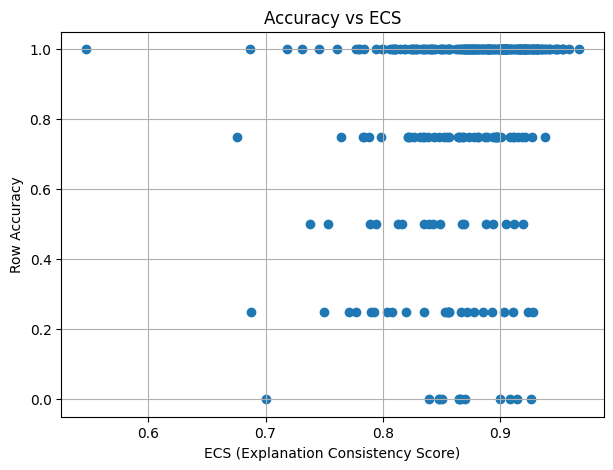

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# TODO: UPDATE THESE PATHS after running the directory listing above
acc_path = "strategyqa_350_perturbed_accuracy.csv"
ecs_path = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"

# Load data
acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)

# Merge on id
merged = acc_df.merge(ecs_df[["id", "ECS"]], on="id", how="inner")

# Plot scatter: ECS vs Accuracy
plt.figure(figsize=(7,5))
plt.scatter(merged["ECS"], merged["row_accuracy"])
plt.xlabel("ECS (Explanation Consistency Score)")
plt.ylabel("Row Accuracy")
plt.title("Accuracy vs ECS")
plt.grid(True)

plt.show()


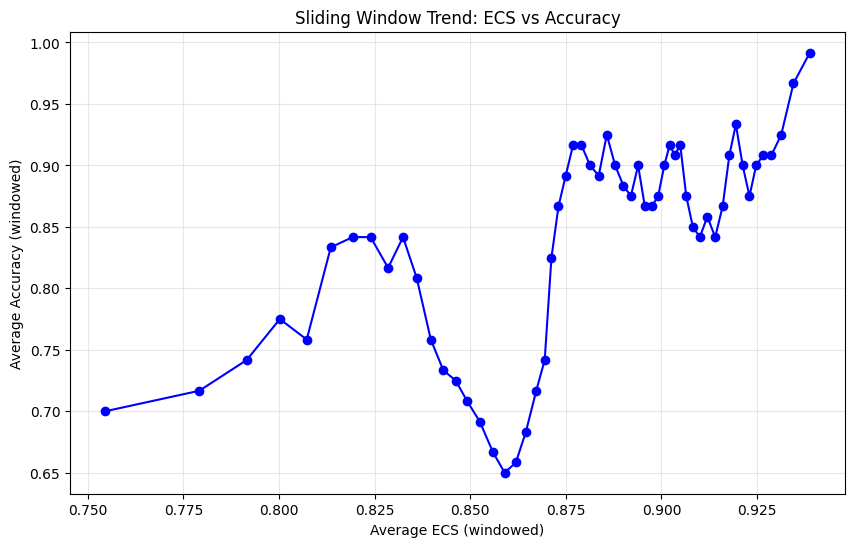

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# Load files
# ================================
acc_path = "strategyqa_350_perturbed_accuracy.csv"
ecs_path = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge on id
df = acc_df.merge(ecs_df, on="id", how="inner")

# Convert to numeric
df["row_accuracy"] = pd.to_numeric(df["row_accuracy"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop rows with missing values
df = df.dropna(subset=["row_accuracy", "ECS"])

# ================================
# Sort by ECS
# ================================
df = df.sort_values(by="ECS").reset_index(drop=True)

# ================================
# Sliding window parameters
# ================================
window_size = 30
step_size = 5

avg_ecs_list = []
avg_acc_list = []

# ================================
# Compute sliding window averages
# ================================
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs = window["ECS"].mean()
    avg_acc = window["row_accuracy"].mean()

    avg_ecs_list.append(avg_ecs)
    avg_acc_list.append(avg_acc)

# ================================
# Visualization
# ================================
plt.figure(figsize=(10,6))
plt.plot(avg_ecs_list, avg_acc_list, marker='o', linestyle='-', color='blue')

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Average Accuracy (windowed)")
plt.title("Sliding Window Trend: ECS vs Accuracy")
plt.grid(alpha=0.3)

plt.show()

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/1851726593.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("ecs_bin").agg(


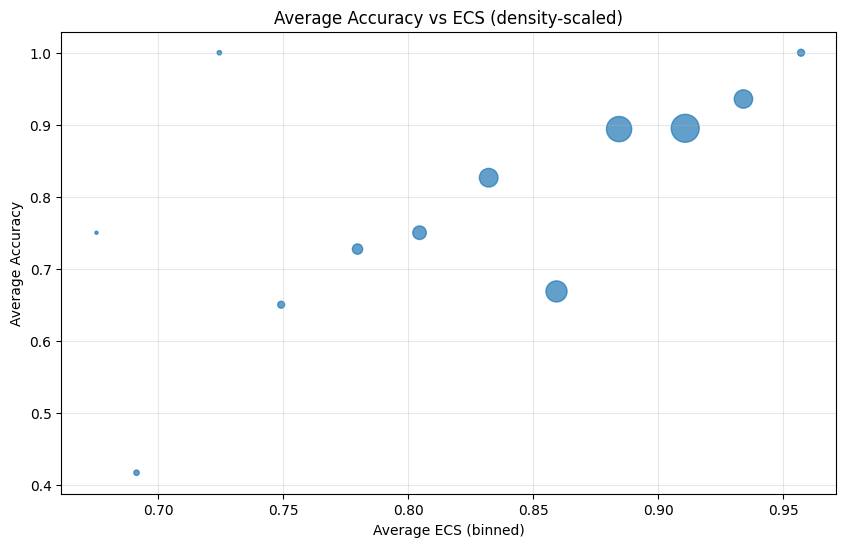

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load data
# ============================
acc_path = "strategyqa_350_perturbed_accuracy.csv"
ecs_path = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge ECS & accuracy into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")

# ============================
# Bin ECS scores
# ============================
bins = np.arange(df["ECS"].min(), df["ECS"].max() + 0.027, 0.027)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

# ============================
# Compute statistics per bin
# ============================
bin_stats = df.groupby("ecs_bin").agg(
    avg_ECS=("ECS", "mean"),
    avg_accuracy=("row_accuracy", "mean"),
    count=("id", "count")
).reset_index()

# ============================
# Scatter Plot
# ============================
plt.figure(figsize=(10,6))
plt.scatter(
    bin_stats["avg_ECS"],
    bin_stats["avg_accuracy"],      # <-- FIXED
    s=bin_stats["count"] * 5,       # marker size = density
    alpha=0.7
)

plt.xlabel("Average ECS (binned)")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy vs ECS (density-scaled)")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
0.024 - 0.027-0.032

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/3378779841.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/3378779841.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/3378779841.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend

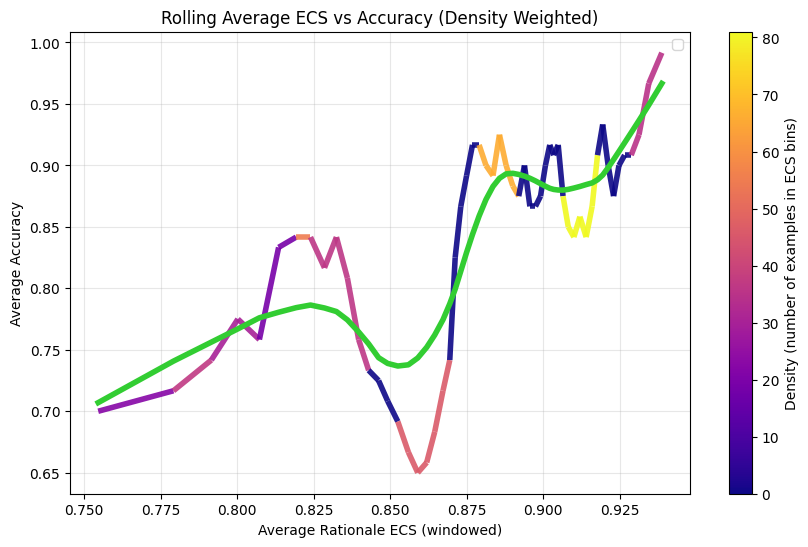

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------
ecs_file = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"
accuracy_file = "strategyqa_350_perturbed_accuracy.csv"


# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
acc_df = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]

# Rename to match the rest of the script ("accuracy")
acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.027
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 30
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    overlapping_bins = bin_stats[(bin_stats["bin_mid"] >= ecs_min) &
                                 (bin_stats["bin_mid"] <= ecs_max)]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth high-density regions (LOWESS)
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # effectively no threshold, keeps all
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

smooth = lowess(acc_high, ecs_high, frac=0.40, return_sorted=True)

smooth_ecs = smooth[:, 0]
smooth_acc = smooth[:, 1]

ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4)

ax.legend()

**SAMPLE 100**

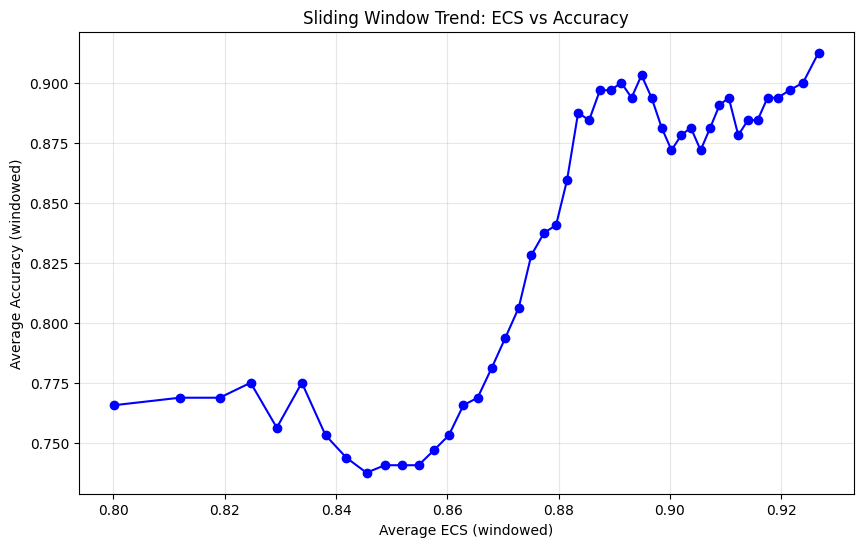

In [459]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# Load files
# ================================
acc_path = "strategyqa_350_perturbed_accuracy.csv"
ecs_path = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge on id
df = acc_df.merge(ecs_df, on="id", how="inner")

# Convert to numeric
df["row_accuracy"] = pd.to_numeric(df["row_accuracy"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop rows with missing values
df = df.dropna(subset=["row_accuracy", "ECS"])

# ================================
# Sort by ECS
# ================================
df = df.sort_values(by="ECS").reset_index(drop=True)

# ================================
# Sliding window parameters
# ================================
window_size = 80
step_size = 5

avg_ecs_list = []
avg_acc_list = []

# ================================
# Compute sliding window averages
# ================================
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs = window["ECS"].mean()
    avg_acc = window["row_accuracy"].mean()

    avg_ecs_list.append(avg_ecs)
    avg_acc_list.append(avg_acc)

# ================================
# Visualization
# ================================
plt.figure(figsize=(10,6))
plt.plot(avg_ecs_list, avg_acc_list, marker='o', linestyle='-', color='blue')

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Average Accuracy (windowed)")
plt.title("Sliding Window Trend: ECS vs Accuracy")
plt.grid(alpha=0.3)

plt.show()

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/376658897.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("ecs_bin").agg(


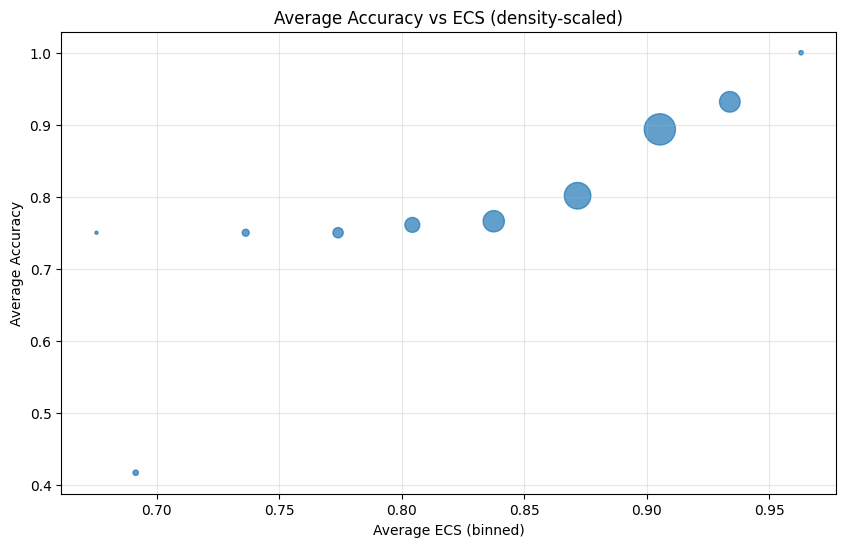

In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load data
# ============================
acc_path = "strategyqa_350_perturbed_accuracy.csv"
ecs_path = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge ECS & accuracy into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")

# ============================
# Bin ECS scores
# ============================
bins = np.arange(df["ECS"].min(), df["ECS"].max() + 0.0341, 0.0341)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

# ============================
# Compute statistics per bin
# ============================
bin_stats = df.groupby("ecs_bin").agg(
    avg_ECS=("ECS", "mean"),
    avg_accuracy=("row_accuracy", "mean"),
    count=("id", "count")
).reset_index()

# ============================
# Scatter Plot
# ============================
plt.figure(figsize=(10,6))
plt.scatter(
    bin_stats["avg_ECS"],
    bin_stats["avg_accuracy"],      # <-- FIXED
    s=bin_stats["count"] * 5,       # marker size = density
    alpha=0.7
)

plt.xlabel("Average ECS (binned)")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy vs ECS (density-scaled)")
plt.grid(alpha=0.3)
plt.show()


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/114767366.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/114767366.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/114767366.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend

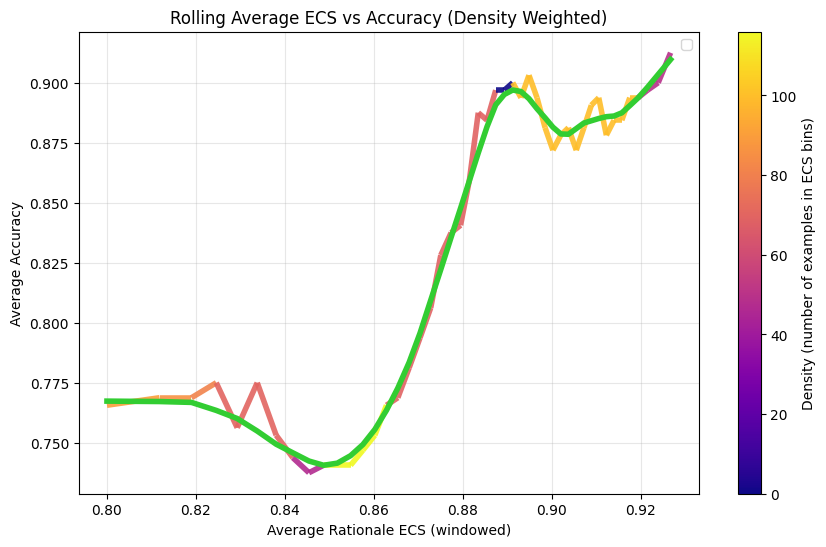

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------
ecs_file = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"
accuracy_file = "strategyqa_350_perturbed_accuracy.csv"


# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
acc_df = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]

# Rename to match the rest of the script ("accuracy")
acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.034
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 80
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    overlapping_bins = bin_stats[(bin_stats["bin_mid"] >= ecs_min) &
                                 (bin_stats["bin_mid"] <= ecs_max)]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth high-density regions (LOWESS)
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # effectively no threshold, keeps all
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

smooth = lowess(acc_high, ecs_high, frac=0.19, return_sorted=True)

smooth_ecs = smooth[:, 0]
smooth_acc = smooth[:, 1]

ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4)

ax.legend()

**Qwen 2.5 - strategyQA**

In [216]:
import pandas as pd

# 1. Load the CSV file
# Make sure the file is in the same folder as the notebook, or give the full path.
df = pd.read_csv("strategyQA_answers_qwen2.5.csv")

# 2. The phrase we want to search for
phrase = """You are an expert reasoner. You must answer using only one of two labels: True or False.

Instructions:
1. Read the question carefully.
2. Think step by step and explain your reasoning in detail.
3. Use any relevant world knowledge needed to answer the question.
4. Do NOT hedge with probabilities or multiple options.
5. At the very end, output the final label on a separate line as exactly:
   Final Answer: True
   or
   Final Answer: False

You will now receive a question.
"""

# 3. Find all cells (except the id column) that contain the phrase
results = []

# Assuming 'id' is the column name for the ID column
id_col = "id"

for col in df.columns:
    if col == id_col:
        continue  # skip the id column itself

    # Convert to string in case of NaNs or non-string values, then search
    mask = df[col].astype(str).str.contains(phrase, regex=False)

    # For every row where the phrase is found, record id + column name
    for idx in df.index[mask]:
        results.append({
            "id": df.at[idx, id_col],
            "column": col
        })

# 4. Create a new DataFrame with two columns: id and column
results_df = pd.DataFrame(results, columns=["id", "column"])

# 5. Sort by id (numeric or string — if numeric, convert first)
# If your IDs are numeric, uncomment the next line:
# results_df["id"] = pd.to_numeric(results_df["id"], errors="coerce")

results_df = results_df.sort_values(by="id")

# 6. Save to a new CSV file
output_filename = "cells_with_prompt_phrase.csv"
results_df.to_csv(output_filename, index=False)

print(f"Done! Saved {len(results_df)} matches to '{output_filename}' (sorted by id).")


Done! Saved 53 matches to 'cells_with_prompt_phrase.csv' (sorted by id).


In [217]:
import pandas as pd

# 1. Load the main file
df = pd.read_csv("strategyQA_answers_qwen2.5.csv")

# 2. Load IDs to remove
remove_df = pd.read_csv("cells_with_prompt_phrase.csv")

# Ensure IDs are comparable (convert both to numeric or both to string)
df["id"] = pd.to_numeric(df["id"], errors="ignore")
remove_df["id"] = pd.to_numeric(remove_df["id"], errors="ignore")

# 3. Remove rows whose ID appears in remove_df
filtered_df = df[~df["id"].isin(remove_df["id"])]

# 4. Save the cleaned version
output_filename = "strategyQA_answers_qwen2.5_cleaned.csv"
filtered_df.to_csv(output_filename, index=False)

print(
    f"Done! Removed {len(df) - len(filtered_df)} rows. "
    f"Saved cleaned file as '{output_filename}'."
)


Done! Removed 46 rows. Saved cleaned file as 'strategyQA_answers_qwen2.5_cleaned.csv'.


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/1493779058.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df["id"] = pd.to_numeric(df["id"], errors="ignore")
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/1493779058.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  remove_df["id"] = pd.to_numeric(remove_df["id"], errors="ignore")


In [218]:
import pandas as pd
import re

# Load the cleaned file
df = pd.read_csv("strategyQA_answers_qwen2.5_cleaned.csv")

# Columns that contain rationales
rationale_cols = ["original_answer", "lexical_answer", "syntactic_answer", "indirect_answer"]

def trim_after_second_final_answer(text):
    """
    Keeps everything before the 2nd occurrence of 'Final Answer:'.
    Removes the 2nd occurrence AND all text after it.
    """
    if not isinstance(text, str):
        return text

    # Find all occurrences of "Final Answer:"
    matches = list(re.finditer(r"Final Answer:", text))

    # If fewer than 2 occurrences → leave untouched
    if len(matches) < 2:
        return text

    # Position of the second occurrence
    second_pos = matches[1].start()

    # Return the part BEFORE the second "Final Answer:"
    return text[:second_pos].rstrip()

# Apply trimming to each rationale column
for col in rationale_cols:
    if col in df.columns:
        df[col] = df[col].apply(trim_after_second_final_answer)

# Save the output
output_filename = "strategyQA_answers_qwen2.5_trimmed.csv"
df.to_csv(output_filename, index=False)

print(f"Done! Saved cleaned file as '{output_filename}'.")


Done! Saved cleaned file as 'strategyQA_answers_qwen2.5_trimmed.csv'.


**start extracting**

In [221]:
import pandas as pd
import re

# Load the trimmed Qwen file
df = pd.read_csv("strategyQA_answers_qwen2.5_trimmed.csv")

# Function to extract Qwen's final answer (always near the end)
def extract_final_answer(text):
    if not isinstance(text, str):
        return None
    
    raw = text
    text = text.strip().lower()

    # Qwen 2.5 typically ends with: "Final Answer: True/False"
    # So first look at the end of the text
    end_match = re.search(r"final answer[:\s\|]*?(true|false)", text[::-1])
    # The reverse trick above is too complex—better direct scan:
    end_match = re.search(r"final answer[:\s\|]*?(true|false)", text)
    if end_match:
        return end_match.group(1).capitalize()

    # General purpose patterns
    patterns = [
        r"final answer[:\s\|]*?(true|false)",           # Final Answer: True
        r"the final answer is[^\w]*(true|false)",       # The final answer is True
        r"answer[:\s]*?(true|false)",                   # Answer: True
        r"\bboxed{(true|false)}",                       # \boxed{True}
    ]
    
    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return match.group(1).capitalize()
    
    # Last-resort fallback: check last 100 chars for "true" / "false"
    tail = text[-120:]  
    if "true" in tail:
        return "True"
    if "false" in tail:
        return "False"

    # If nothing is found
    return "UNKNOWN"

# Build output dataframe
out_df = pd.DataFrame()
out_df["id"] = df["id"]

out_df["original_answer"]  = df["original_answer"].apply(extract_final_answer)
out_df["lexical_answer"]   = df["lexical_answer"].apply(extract_final_answer)
out_df["syntactic_answer"] = df["syntactic_answer"].apply(extract_final_answer)
out_df["indirect_answer"]  = df["indirect_answer"].apply(extract_final_answer)

# If your CSV contains the gold label column:
if "gold_answer" in df.columns:
    out_df["gold_answer"] = df["gold_answer"]

# Save final extracted answers
output_path = "strategyQA_answers_qwen2.5_final_answers.csv"
out_df.to_csv(output_path, index=False)

print("Extraction for Qwen completed! Saved to:", output_path)


Extraction for Qwen completed! Saved to: strategyQA_answers_qwen2.5_final_answers.csv


In [220]:
import pandas as pd

# Load the file
df = pd.read_csv("strategyQA_answers_qwen2.5_trimmed.csv")

# ID to remove
remove_id = 131

# Ensure ID column is numeric (optional but safe)
df["id"] = pd.to_numeric(df["id"], errors="ignore")

# Remove the row
df_clean = df[df["id"] != remove_id]

# Save back to a new file (or overwrite the original if you prefer)
df_clean.to_csv("strategyQA_answers_qwen2.5_trimmed.csv", index=False)

print(f"Removed row with id={remove_id}. New file saved!")


Removed row with id=131. New file saved!


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/1009179339.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df["id"] = pd.to_numeric(df["id"], errors="ignore")


In [222]:
import pandas as pd

# Load both files
perturbed = pd.read_csv("strategyqa_350_perturbed.csv")
qwen = pd.read_csv("strategyQA_answers_qwen2.5_final_answers.csv")

# Ensure id column types match
perturbed["id"] = pd.to_numeric(perturbed["id"], errors="ignore")
qwen["id"] = pd.to_numeric(qwen["id"], errors="ignore")

# Keep only id + answer from the perturbed file
perturbed_subset = perturbed[["id", "answer"]].rename(columns={"answer": "target_answer"})

# Merge based on id
merged = qwen.merge(perturbed_subset, on="id", how="left")

# Save result
output_file = "strategyQA_answers_qwen2.5_final_answers_with_targets.csv"
merged.to_csv(output_file, index=False)

print("Done! Saved merged file as:", output_file)


Done! Saved merged file as: strategyQA_answers_qwen2.5_final_answers_with_targets.csv


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/1629476723.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  perturbed["id"] = pd.to_numeric(perturbed["id"], errors="ignore")
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/1629476723.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  qwen["id"] = pd.to_numeric(qwen["id"], errors="ignore")


In [224]:
import pandas as pd

# Input + Output files
input_file = "strategyqa_350_perturbed_qwen2.5_final_answers.csv"
output_file = "strategyqa_350_perturbed_qwen2.5_accuracy.csv"

# Load data
df = pd.read_csv(input_file)

# Columns containing extracted model answers
cols_to_check = [
    "original_answer",
    "lexical_answer",
    "syntactic_answer",
    "indirect_answer"
]

# Normalize formatting for comparison
df["gold_answer"] = df["target_answer"].astype(str).str.strip().str.capitalize()

for c in cols_to_check:
    df[c] = df[c].astype(str).str.strip().str.capitalize()

# Function to compute accuracy for each row
def row_accuracy(row):
    correct = row["gold_answer"]
    total = len(cols_to_check)
    matches = sum(row[col] == correct for col in cols_to_check)
    return matches / total

# Apply accuracy function
df["row_accuracy"] = df.apply(row_accuracy, axis=1)

# Save the results
df.to_csv(output_file, index=False)

print("🎉 Accuracy computed successfully!")
print("💾 Saved to:", output_file)

# Show preview
df.head()

🎉 Accuracy computed successfully!
💾 Saved to: strategyqa_350_perturbed_qwen2.5_accuracy.csv


,id,original_answer,lexical_answer,syntactic_answer,indirect_answer,target_answer,gold_answer,row_accuracy
0,1,True,True,True,True,True,True,1.00
1,2,False,False,False,False,False,False,1.00
2,3,False,False,False,False,False,False,1.00
3,5,True,False,True,True,False,False,0.25
4,6,False,False,False,True,False,False,0.75


In [225]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
from itertools import combinations
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load the file
# =====================================================
input_file = "strategyQA_answers_qwen2.5_trimmed.csv"
output_file = "strategyQA_answers_qwen2.5_trimmed_with_ecs.csv"

df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")

# =====================================================
# STEP 2: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")

# =====================================================
# STEP 3: Define ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute Explanation Consistency Score (semantic meaning)
    = mean cosine similarity between all pairs of explanations.
    """
    # Keep only valid text
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b], normalize_embeddings=True)
        sim = float(np.dot(emb[0], emb[1]))  # cosine similarity
        sim_scores.append(sim)

    return np.mean(sim_scores)

# =====================================================
# STEP 4: Compute ECS for each row
# =====================================================
ecs_values = []

print("🧮 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    ecs = compute_ecs_semantic([
        row.get("original_answer"),
        row.get("lexical_answer"),
        row.get("syntactic_answer"),
        row.get("indirect_answer"),
    ])
    ecs_values.append(ecs)

df["ECS"] = ecs_values

# =====================================================
# STEP 5: Compute overall mean ECS
# =====================================================
overall_ecs = np.nanmean(df["ECS"])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.4f}")

# =====================================================
# STEP 6: Save results
# =====================================================
df.to_csv(output_file, index=False)
print(f"💾 Saved ECS-annotated results to {output_file}")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 303 rows from strategyQA_answers_qwen2.5_trimmed.csv
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing ECS (semantic consistency) for each example...


  0%|          | 0/303 [00:00<?, ?it/s]


🔍 Average Explanation Consistency Score (ECS): 0.8714
💾 Saved ECS-annotated results to strategyQA_answers_qwen2.5_trimmed_with_ecs.csv


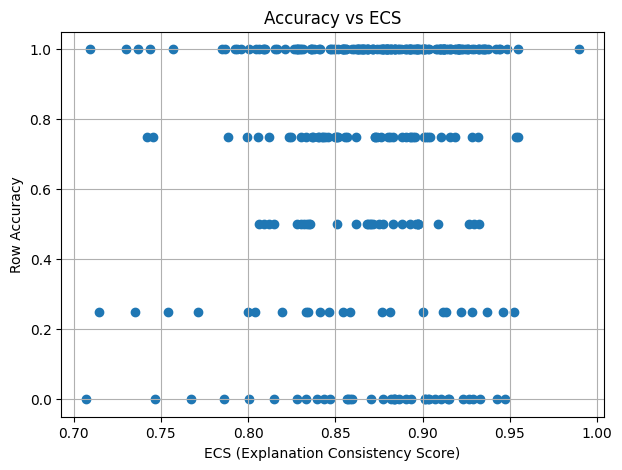

In [226]:
import pandas as pd
import matplotlib.pyplot as plt

# TODO: UPDATE THESE PATHS after running the directory listing above
acc_path = "strategyqa_350_perturbed_qwen2.5_accuracy.csv"
ecs_path = "strategyQA_answers_qwen2.5_trimmed_with_ecs.csv"

# Load data
acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)

# Merge on id
merged = acc_df.merge(ecs_df[["id", "ECS"]], on="id", how="inner")

# Plot scatter: ECS vs Accuracy
plt.figure(figsize=(7,5))
plt.scatter(merged["ECS"], merged["row_accuracy"])
plt.xlabel("ECS (Explanation Consistency Score)")
plt.ylabel("Row Accuracy")
plt.title("Accuracy vs ECS")
plt.grid(True)

plt.show()


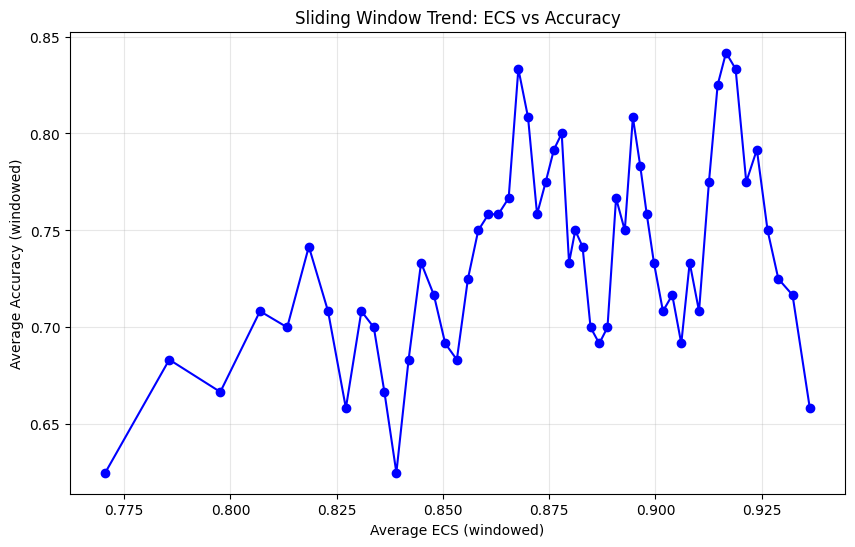

In [230]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# Load files
# ================================
acc_path = "strategyqa_350_perturbed_qwen2.5_accuracy.csv"
ecs_path = "strategyQA_answers_qwen2.5_trimmed_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge on id
df = acc_df.merge(ecs_df, on="id", how="inner")

# Convert to numeric
df["row_accuracy"] = pd.to_numeric(df["row_accuracy"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop rows with missing values
df = df.dropna(subset=["row_accuracy", "ECS"])

# ================================
# Sort by ECS
# ================================
df = df.sort_values(by="ECS").reset_index(drop=True)

# ================================
# Sliding window parameters
# ================================
window_size =
step_size = 5

avg_ecs_list = []
avg_acc_list = []

# ================================
# Compute sliding window averages
# ================================
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs = window["ECS"].mean()
    avg_acc = window["row_accuracy"].mean()

    avg_ecs_list.append(avg_ecs)
    avg_acc_list.append(avg_acc)

# ================================
# Visualization
# ================================
plt.figure(figsize=(10,6))
plt.plot(avg_ecs_list, avg_acc_list, marker='o', linestyle='-', color='blue')

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Average Accuracy (windowed)")
plt.title("Sliding Window Trend: ECS vs Accuracy")
plt.grid(alpha=0.3)

plt.show()

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/4078155193.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("ecs_bin").agg(


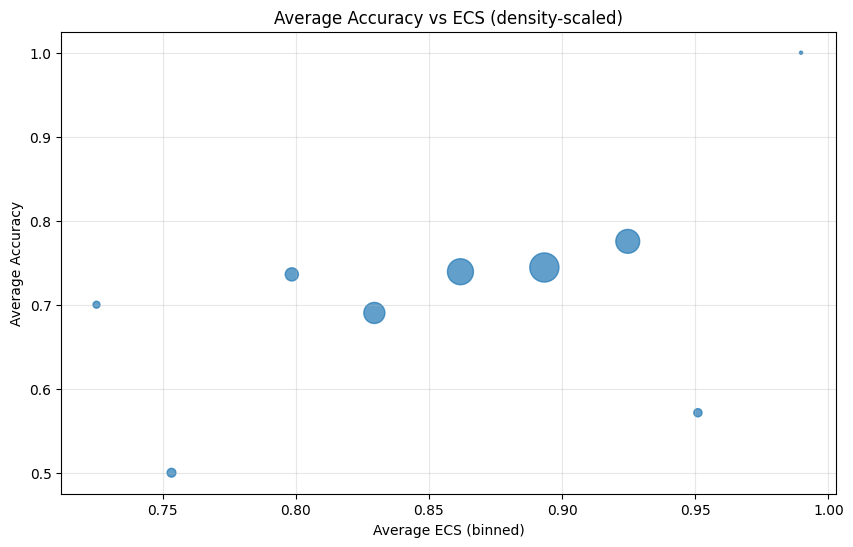

In [285]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load data
# ============================
acc_path = "strategyqa_350_perturbed_qwen2.5_accuracy.csv"
ecs_path = "strategyQA_answers_qwen2.5_trimmed_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge ECS & accuracy into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")

# ============================
# Bin ECS scores
# ============================
bins = np.arange(df["ECS"].min(), df["ECS"].max() + 0.034, 0.034)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

# ============================
# Compute statistics per bin
# ============================
bin_stats = df.groupby("ecs_bin").agg(
    avg_ECS=("ECS", "mean"),
    avg_accuracy=("row_accuracy", "mean"),
    count=("id", "count")
).reset_index()

# ============================
# Scatter Plot
# ============================
plt.figure(figsize=(10,6))
plt.scatter(
    bin_stats["avg_ECS"],
    bin_stats["avg_accuracy"],      # <-- FIXED
    s=bin_stats["count"] * 5,       # marker size = density
    alpha=0.7
)

plt.xlabel("Average ECS (binned)")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy vs ECS (density-scaled)")
plt.grid(alpha=0.3)
plt.show()


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/3078327755.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/3078327755.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/3078327755.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend

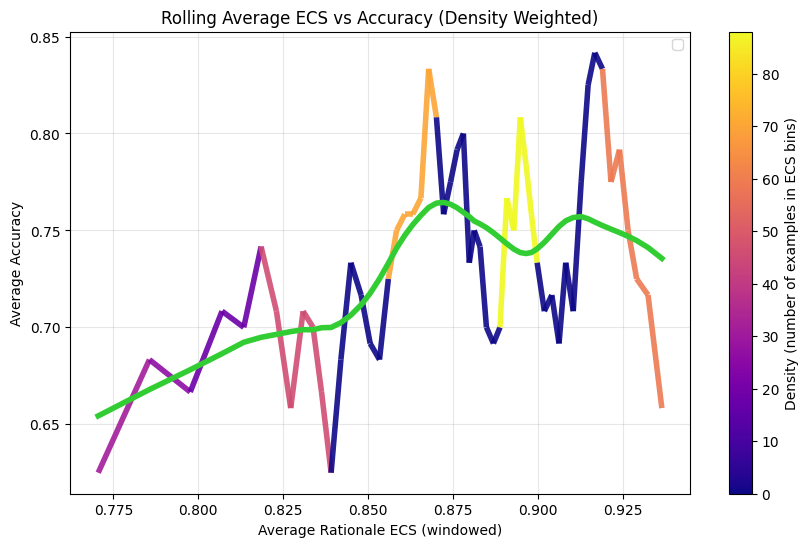

In [291]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------

ecs_file = "strategyQA_answers_qwen2.5_trimmed_with_ecs.csv"
accuracy_file = "strategyqa_350_perturbed_qwen2.5_accuracy.csv"


# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
acc_df = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]

# Rename to match the rest of the script ("accuracy")
acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.034
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 30
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    overlapping_bins = bin_stats[(bin_stats["bin_mid"] >= ecs_min) &
                                 (bin_stats["bin_mid"] <= ecs_max)]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth high-density regions (LOWESS)
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # effectively no threshold, keeps all
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

smooth = lowess(acc_high, ecs_high, frac=0.40, return_sorted=True)

smooth_ecs = smooth[:, 0]
smooth_acc = smooth[:, 1]

ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4)

ax.legend()

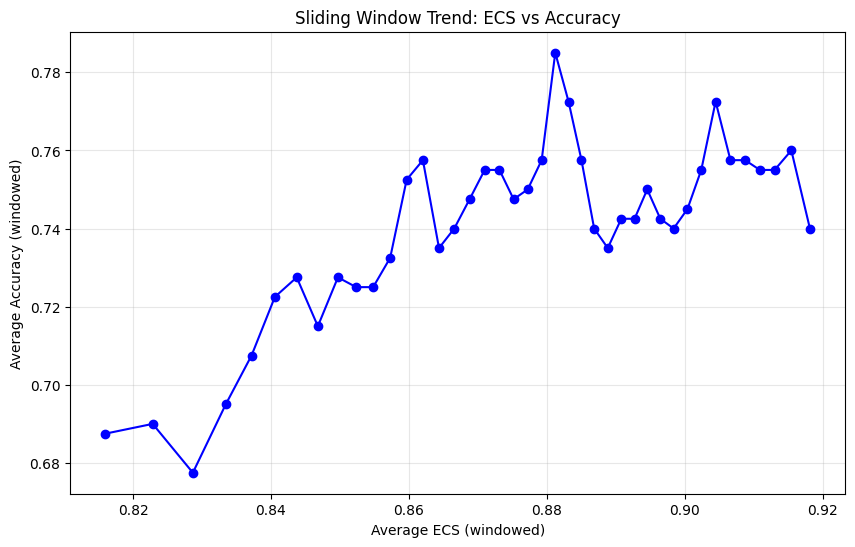

In [292]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# Load files
# ================================
acc_path = "strategyqa_350_perturbed_qwen2.5_accuracy.csv"
ecs_path = "strategyQA_answers_qwen2.5_trimmed_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge on id
df = acc_df.merge(ecs_df, on="id", how="inner")

# Convert to numeric
df["row_accuracy"] = pd.to_numeric(df["row_accuracy"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop rows with missing values
df = df.dropna(subset=["row_accuracy", "ECS"])

# ================================
# Sort by ECS
# ================================
df = df.sort_values(by="ECS").reset_index(drop=True)

# ================================
# Sliding window parameters
# ================================
window_size = 100
step_size = 5

avg_ecs_list = []
avg_acc_list = []

# ================================
# Compute sliding window averages
# ================================
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs = window["ECS"].mean()
    avg_acc = window["row_accuracy"].mean()

    avg_ecs_list.append(avg_ecs)
    avg_acc_list.append(avg_acc)

# ================================
# Visualization
# ================================
plt.figure(figsize=(10,6))
plt.plot(avg_ecs_list, avg_acc_list, marker='o', linestyle='-', color='blue')

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Average Accuracy (windowed)")
plt.title("Sliding Window Trend: ECS vs Accuracy")
plt.grid(alpha=0.3)

plt.show()

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/2647378387.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("ecs_bin").agg(


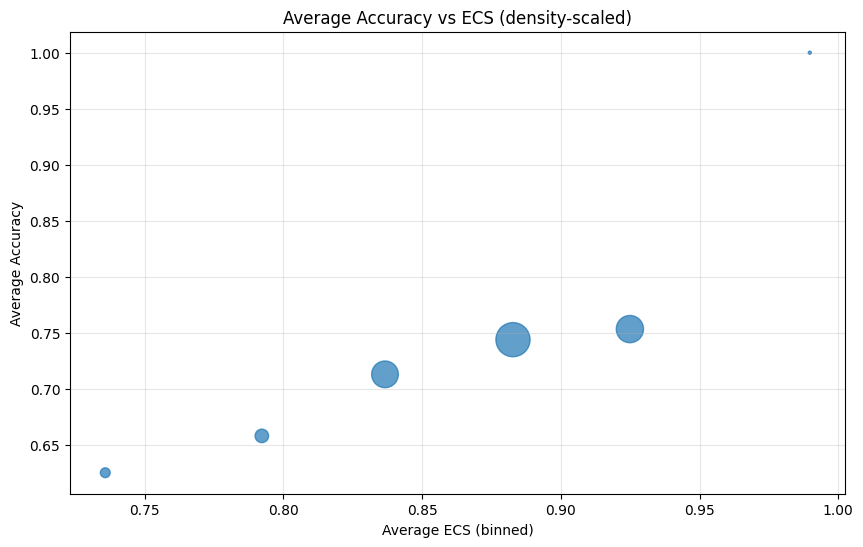

In [294]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load data
# ============================
acc_path = "strategyqa_350_perturbed_qwen2.5_accuracy.csv"
ecs_path = "strategyQA_answers_qwen2.5_trimmed_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge ECS & accuracy into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")

# ============================
# Bin ECS scores
# ============================
bins = np.arange(df["ECS"].min(), df["ECS"].max() + 0.05, 0.05)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

# ============================
# Compute statistics per bin
# ============================
bin_stats = df.groupby("ecs_bin").agg(
    avg_ECS=("ECS", "mean"),
    avg_accuracy=("row_accuracy", "mean"),
    count=("id", "count")
).reset_index()

# ============================
# Scatter Plot
# ============================
plt.figure(figsize=(10,6))
plt.scatter(
    bin_stats["avg_ECS"],
    bin_stats["avg_accuracy"],      # <-- FIXED
    s=bin_stats["count"] * 5,       # marker size = density
    alpha=0.7
)

plt.xlabel("Average ECS (binned)")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy vs ECS (density-scaled)")
plt.grid(alpha=0.3)
plt.show()

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/1808814963.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/1808814963.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/1808814963.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.leg

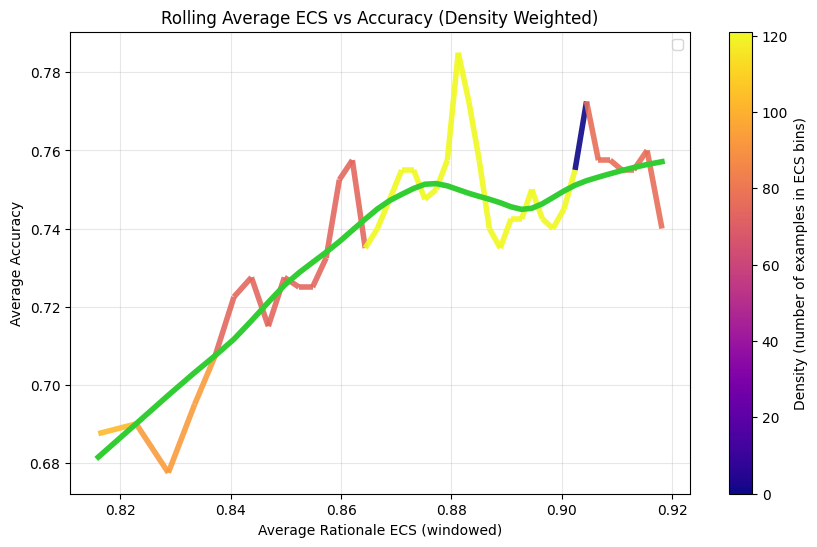

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------

ecs_file = "strategyQA_answers_qwen2.5_trimmed_with_ecs.csv"
accuracy_file = "strategyqa_350_perturbed_qwen2.5_accuracy.csv"


# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
acc_df = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]

# Rename to match the rest of the script ("accuracy")
acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.05
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    overlapping_bins = bin_stats[(bin_stats["bin_mid"] >= ecs_min) &
                                 (bin_stats["bin_mid"] <= ecs_max)]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth high-density regions (LOWESS)
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # effectively no threshold, keeps all
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

smooth = lowess(acc_high, ecs_high, frac=0.40, return_sorted=True)

smooth_ecs = smooth[:, 0]
smooth_acc = smooth[:, 1]

ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4)

ax.legend()

**mistral v0.3 - strategyQA**

In [301]:
import pandas as pd

# Load the file
df = pd.read_csv("strategyQA__mistral_rationales.csv")

# List of IDs to remove — EDIT THIS LIST
remove_ids = [14,21,23,26,27,33,40,46,59,61,74,83,86,92,94,96,97,102,110,114,116,117,118,
             158,161,162,168,183,185,186,188,189,194,196,213,235,237,239,255,257,259,265,
            268,269, 273,286,290,312,313,324,333,345,349]   # <-- add or remove IDs as needed

# Ensure ID column type is consistent
df["id"] = pd.to_numeric(df["id"], errors="ignore")

# Filter out rows whose ID is in the list
df_clean = df[~df["id"].isin(remove_ids)]

# Save cleaned version
output_file = "strategyQA__mistral_rationales_cleaned.csv"
df_clean.to_csv(output_file, index=False)

print(f"Removed {len(df) - len(df_clean)} rows. Saved cleaned file to {output_file}.")


Removed 53 rows. Saved cleaned file to strategyQA__mistral_rationales_cleaned.csv.


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_4099/3680425405.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df["id"] = pd.to_numeric(df["id"], errors="ignore")


In [302]:
import pandas as pd
import re

# Load the trimmed Qwen file
df = pd.read_csv("strategyQA__mistral_rationales_cleaned.csv")

# Function to extract Qwen's final answer (always near the end)
def extract_final_answer(text):
    if not isinstance(text, str):
        return None
    
    raw = text
    text = text.strip().lower()

    # Qwen 2.5 typically ends with: "Final Answer: True/False"
    # So first look at the end of the text
    end_match = re.search(r"final answer[:\s\|]*?(true|false)", text[::-1])
    # The reverse trick above is too complex—better direct scan:
    end_match = re.search(r"final answer[:\s\|]*?(true|false)", text)
    if end_match:
        return end_match.group(1).capitalize()

    # General purpose patterns
    patterns = [
        r"final answer[:\s\|]*?(true|false)",           # Final Answer: True
        r"the final answer is[^\w]*(true|false)",       # The final answer is True
        r"answer[:\s]*?(true|false)",                   # Answer: True
        r"\bboxed{(true|false)}",                       # \boxed{True}
    ]
    
    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return match.group(1).capitalize()
    
    # Last-resort fallback: check last 100 chars for "true" / "false"
    tail = text[-120:]  
    if "true" in tail:
        return "True"
    if "false" in tail:
        return "False"

    # If nothing is found
    return "UNKNOWN"

# Build output dataframe
out_df = pd.DataFrame()
out_df["id"] = df["id"]

out_df["original_answer"]  = df["original_answer"].apply(extract_final_answer)
out_df["lexical_answer"]   = df["lexical_answer"].apply(extract_final_answer)
out_df["syntactic_answer"] = df["syntactic_answer"].apply(extract_final_answer)
out_df["indirect_answer"]  = df["indirect_answer"].apply(extract_final_answer)

# If your CSV contains the gold label column:
if "gold_answer" in df.columns:
    out_df["gold_answer"] = df["gold_answer"]

# Save final extracted answers
output_path = "strategyQA__mistral_rationales_final_answers.csv"
out_df.to_csv(output_path, index=False)

print("Extraction for Qwen completed! Saved to:", output_path)

Extraction for Qwen completed! Saved to: strategyQA__mistral_rationales_final_answers.csv


In [303]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
from itertools import combinations
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# STEP 1: Load the file
# =====================================================
input_file = "strategyQA__mistral_rationales_cleaned.csv"
output_file = "strategyQA__mistral_rationales_with_ecs.csv"

df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")

# =====================================================
# STEP 2: Initialize embedding model
# =====================================================
print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")

# =====================================================
# STEP 3: Define ECS computation function
# =====================================================
def compute_ecs_semantic(rationales):
    """
    Compute Explanation Consistency Score (semantic meaning)
    = mean cosine similarity between all pairs of explanations.
    """
    # Keep only valid text
    texts = [t for t in rationales if isinstance(t, str) and t.strip()]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    sim_scores = []

    for a, b in pairs:
        emb = model.encode([a, b], normalize_embeddings=True)
        sim = float(np.dot(emb[0], emb[1]))  # cosine similarity
        sim_scores.append(sim)

    return np.mean(sim_scores)

# =====================================================
# STEP 4: Compute ECS for each row
# =====================================================
ecs_values = []

print("🧮 Computing ECS (semantic consistency) for each example...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    ecs = compute_ecs_semantic([
        row.get("original_answer"),
        row.get("lexical_answer"),
        row.get("syntactic_answer"),
        row.get("indirect_answer"),
    ])
    ecs_values.append(ecs)

df["ECS"] = ecs_values

# =====================================================
# STEP 5: Compute overall mean ECS
# =====================================================
overall_ecs = np.nanmean(df["ECS"])
print(f"\n🔍 Average Explanation Consistency Score (ECS): {overall_ecs:.4f}")

# =====================================================
# STEP 6: Save results
# =====================================================
df.to_csv(output_file, index=False)
print(f"💾 Saved ECS-annotated results to {output_file}")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 297 rows from strategyQA__mistral_rationales_cleaned.csv
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing ECS (semantic consistency) for each example...


  0%|          | 0/297 [00:00<?, ?it/s]


🔍 Average Explanation Consistency Score (ECS): 0.8613
💾 Saved ECS-annotated results to strategyQA__mistral_rationales_with_ecs.csv


In [1]:
import pandas as pd

# Load both files
perturbed = pd.read_csv("strategyqa_350_perturbed.csv")
qwen = pd.read_csv("strategyQA__mistral_rationales_final_answers.csv")

# Ensure id column types match
perturbed["id"] = pd.to_numeric(perturbed["id"], errors="ignore")
qwen["id"] = pd.to_numeric(qwen["id"], errors="ignore")

# Keep only id + answer from the perturbed file
perturbed_subset = perturbed[["id", "answer"]].rename(columns={"answer": "target_answer"})

# Merge based on id
merged = qwen.merge(perturbed_subset, on="id", how="left")

# Save result
output_file = "strategyQA_answers_mistral2.5_final_answers_with_targets.csv"
merged.to_csv(output_file, index=False)

print("Done! Saved merged file as:", output_file)


Done! Saved merged file as: strategyQA_answers_mistral2.5_final_answers_with_targets.csv


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_964/2103104268.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  perturbed["id"] = pd.to_numeric(perturbed["id"], errors="ignore")
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_964/2103104268.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  qwen["id"] = pd.to_numeric(qwen["id"], errors="ignore")


In [2]:
import pandas as pd

# Input + Output files
input_file = "strategyQA_answers_mistral2.5_final_answers_with_targets.csv"
output_file = "strategyQA__mistral_rationales_accuracy.csv"

# Load data
df = pd.read_csv(input_file)

# Columns containing extracted model answers
cols_to_check = [
    "original_answer",
    "lexical_answer",
    "syntactic_answer",
    "indirect_answer"
]

# Normalize formatting for comparison
df["gold_answer"] = df["target_answer"].astype(str).str.strip().str.capitalize()

for c in cols_to_check:
    df[c] = df[c].astype(str).str.strip().str.capitalize()

# Function to compute accuracy for each row
def row_accuracy(row):
    correct = row["gold_answer"]
    total = len(cols_to_check)
    matches = sum(row[col] == correct for col in cols_to_check)
    return matches / total

# Apply accuracy function
df["row_accuracy"] = df.apply(row_accuracy, axis=1)

# Save the results
df.to_csv(output_file, index=False)

print("🎉 Accuracy computed successfully!")
print("💾 Saved to:", output_file)

# Show preview
df.head()

🎉 Accuracy computed successfully!
💾 Saved to: strategyQA__mistral_rationales_accuracy.csv


,id,original_answer,lexical_answer,syntactic_answer,indirect_answer,target_answer,gold_answer,row_accuracy
0,1,True,True,True,True,True,True,1.00
1,2,False,False,False,False,False,False,1.00
2,3,False,False,False,False,False,False,1.00
3,4,False,True,True,False,True,True,0.50
4,5,True,False,True,True,False,False,0.25


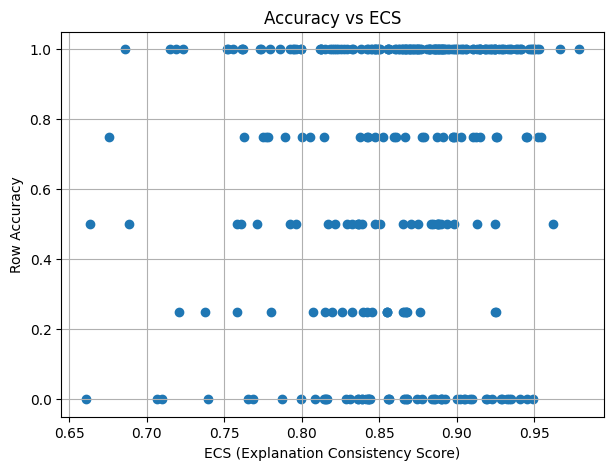

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# TODO: UPDATE THESE PATHS after running the directory listing above
acc_path = "strategyQA__mistral_rationales_accuracy.csv"
ecs_path = "strategyQA__mistral_rationales_with_ecs.csv"

# Load data
acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)

# Merge on id
merged = acc_df.merge(ecs_df[["id", "ECS"]], on="id", how="inner")

# Plot scatter: ECS vs Accuracy
plt.figure(figsize=(7,5))
plt.scatter(merged["ECS"], merged["row_accuracy"])
plt.xlabel("ECS (Explanation Consistency Score)")
plt.ylabel("Row Accuracy")
plt.title("Accuracy vs ECS")
plt.grid(True)

plt.show()


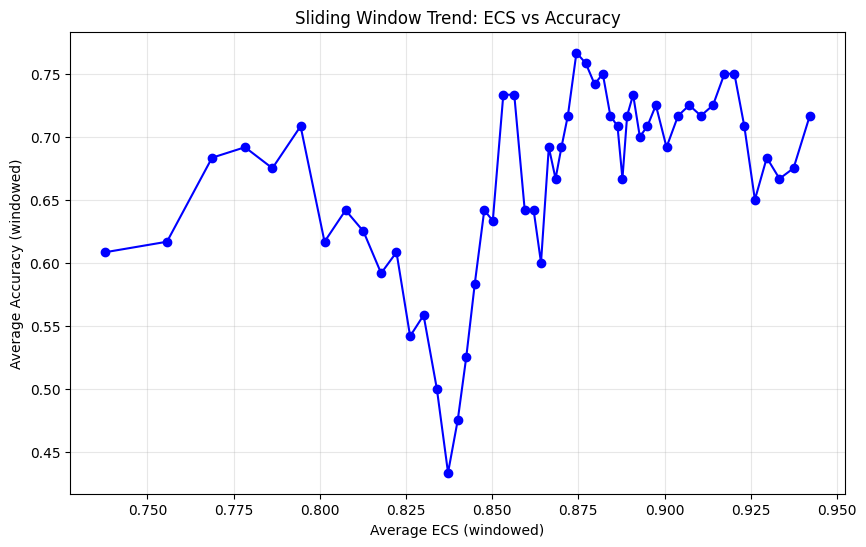

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# Load files
# ================================
acc_path = "strategyQA__mistral_rationales_accuracy.csv"
ecs_path = "strategyQA__mistral_rationales_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge on id
df = acc_df.merge(ecs_df, on="id", how="inner")

# Convert to numeric
df["row_accuracy"] = pd.to_numeric(df["row_accuracy"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop rows with missing values
df = df.dropna(subset=["row_accuracy", "ECS"])

# ================================
# Sort by ECS
# ================================
df = df.sort_values(by="ECS").reset_index(drop=True)

# ================================
# Sliding window parameters
# ================================
window_size = 30
step_size = 5

avg_ecs_list = []
avg_acc_list = []

# ================================
# Compute sliding window averages
# ================================
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs = window["ECS"].mean()
    avg_acc = window["row_accuracy"].mean()

    avg_ecs_list.append(avg_ecs)
    avg_acc_list.append(avg_acc)

# ================================
# Visualization
# ================================
plt.figure(figsize=(10,6))
plt.plot(avg_ecs_list, avg_acc_list, marker='o', linestyle='-', color='blue')

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Average Accuracy (windowed)")
plt.title("Sliding Window Trend: ECS vs Accuracy")
plt.grid(alpha=0.3)

plt.show()

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_964/4154414793.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("ecs_bin").agg(


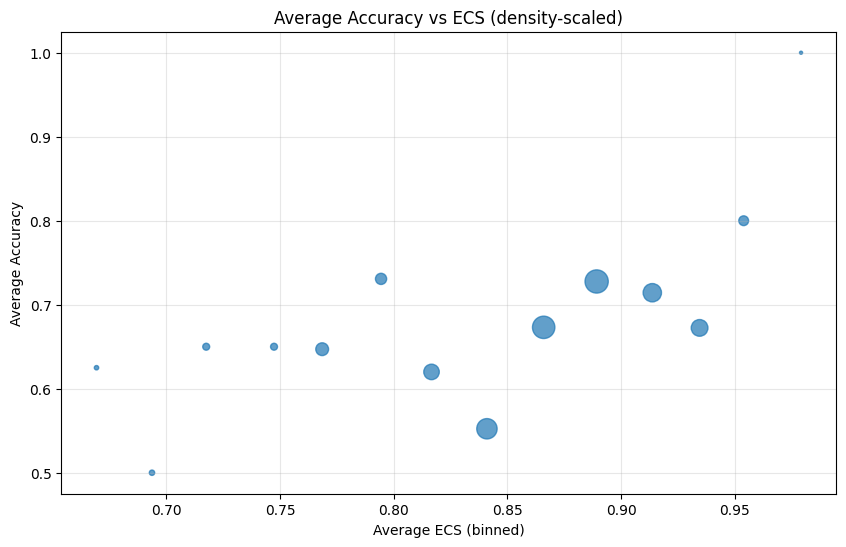

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load data
# ============================
acc_path = "strategyQA__mistral_rationales_accuracy.csv"
ecs_path = "strategyQA__mistral_rationales_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge ECS & accuracy into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")

# ============================
# Bin ECS scores
# ============================
bins = np.arange(df["ECS"].min(), df["ECS"].max() + 0.024, 0.024)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

# ============================
# Compute statistics per bin
# ============================
bin_stats = df.groupby("ecs_bin").agg(
    avg_ECS=("ECS", "mean"),
    avg_accuracy=("row_accuracy", "mean"),
    count=("id", "count")
).reset_index()

# ============================
# Scatter Plot
# ============================
plt.figure(figsize=(10,6))
plt.scatter(
    bin_stats["avg_ECS"],
    bin_stats["avg_accuracy"],      # <-- FIXED
    s=bin_stats["count"] * 5,       # marker size = density
    alpha=0.7
)

plt.xlabel("Average ECS (binned)")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy vs ECS (density-scaled)")
plt.grid(alpha=0.3)
plt.show()

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_964/2365444277.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_964/2365444277.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_964/2365444277.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


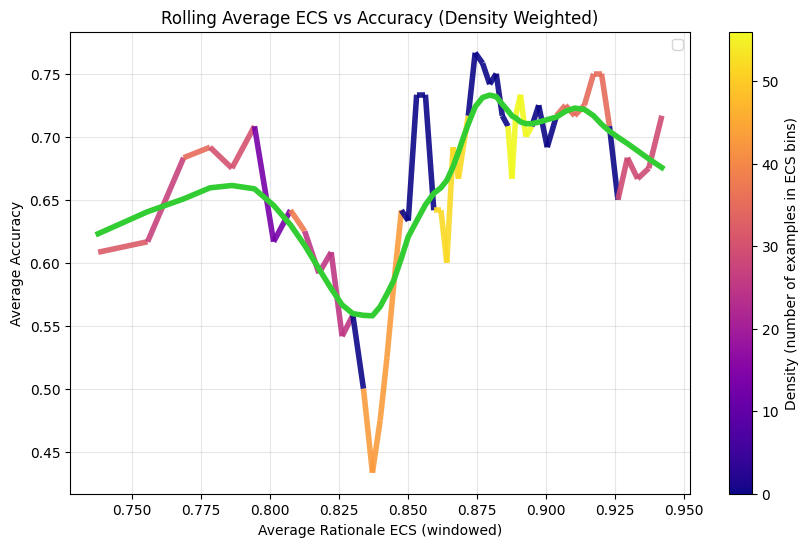

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------


ecs_file = "strategyQA__mistral_rationales_with_ecs.csv"
accuracy_file = "strategyQA__mistral_rationales_accuracy.csv"


# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
acc_df = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]

# Rename to match the rest of the script ("accuracy")
acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.024
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 30
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    overlapping_bins = bin_stats[(bin_stats["bin_mid"] >= ecs_min) &
                                 (bin_stats["bin_mid"] <= ecs_max)]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth high-density regions (LOWESS)
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # effectively no threshold, keeps all
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

smooth = lowess(acc_high, ecs_high, frac=0.25, return_sorted=True)

smooth_ecs = smooth[:, 0]
smooth_acc = smooth[:, 1]

ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4)

ax.legend()

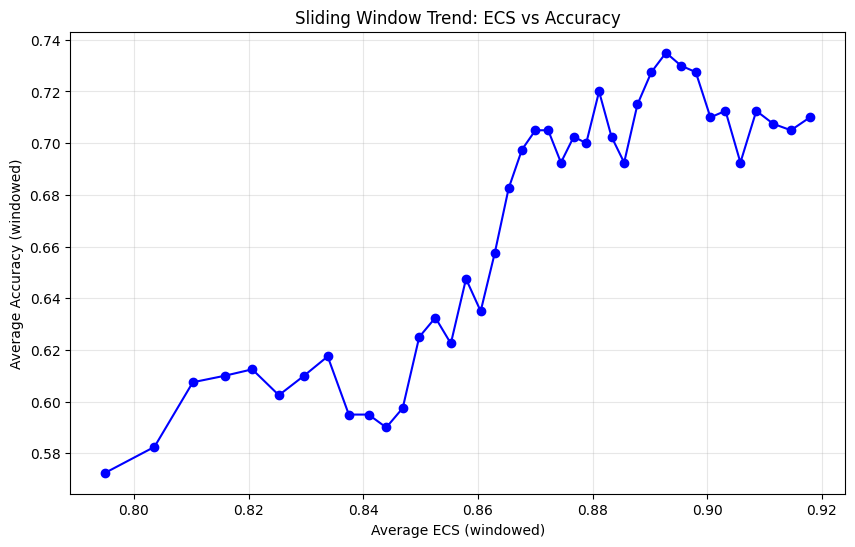

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# Load files
# ================================
acc_path = "strategyQA__mistral_rationales_accuracy.csv"
ecs_path = "strategyQA__mistral_rationales_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge on id
df = acc_df.merge(ecs_df, on="id", how="inner")

# Convert to numeric
df["row_accuracy"] = pd.to_numeric(df["row_accuracy"], errors="coerce")
df["ECS"] = pd.to_numeric(df["ECS"], errors="coerce")

# Drop rows with missing values
df = df.dropna(subset=["row_accuracy", "ECS"])

# ================================
# Sort by ECS
# ================================
df = df.sort_values(by="ECS").reset_index(drop=True)

# ================================
# Sliding window parameters
# ================================
window_size = 100
step_size = 5

avg_ecs_list = []
avg_acc_list = []

# ================================
# Compute sliding window averages
# ================================
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs = window["ECS"].mean()
    avg_acc = window["row_accuracy"].mean()

    avg_ecs_list.append(avg_ecs)
    avg_acc_list.append(avg_acc)

# ================================
# Visualization
# ================================
plt.figure(figsize=(10,6))
plt.plot(avg_ecs_list, avg_acc_list, marker='o', linestyle='-', color='blue')

plt.xlabel("Average ECS (windowed)")
plt.ylabel("Average Accuracy (windowed)")
plt.title("Sliding Window Trend: ECS vs Accuracy")
plt.grid(alpha=0.3)

plt.show()

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_964/4254641892.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("ecs_bin").agg(


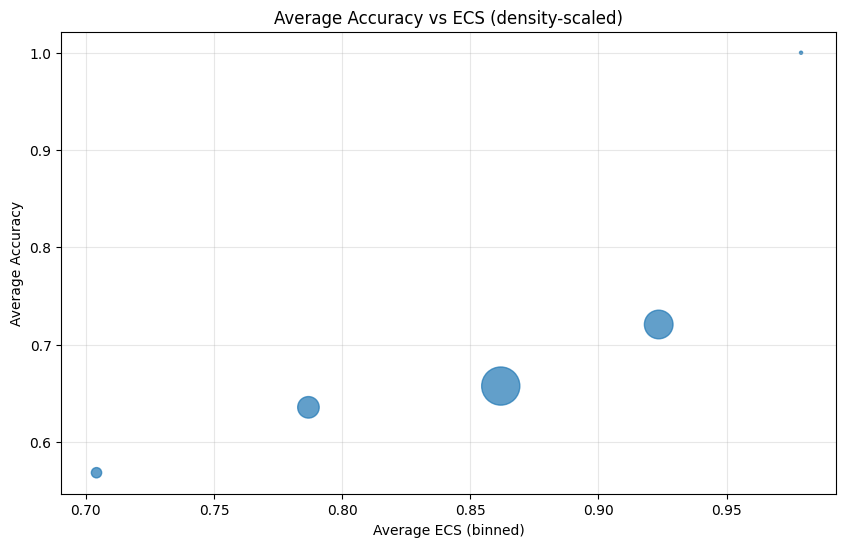

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================
# Load data
# ============================
acc_path = "strategyQA__mistral_rationales_accuracy.csv"
ecs_path = "strategyQA__mistral_rationales_with_ecs.csv"

acc_df = pd.read_csv(acc_path)
ecs_df = pd.read_csv(ecs_path)[["id", "ECS"]]

# Merge ECS & accuracy into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")

# ============================
# Bin ECS scores
# ============================
bins = np.arange(df["ECS"].min(), df["ECS"].max() + 0.078, 0.078)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

# ============================
# Compute statistics per bin
# ============================
bin_stats = df.groupby("ecs_bin").agg(
    avg_ECS=("ECS", "mean"),
    avg_accuracy=("row_accuracy", "mean"),
    count=("id", "count")
).reset_index()

# ============================
# Scatter Plot
# ============================
plt.figure(figsize=(10,6))
plt.scatter(
    bin_stats["avg_ECS"],
    bin_stats["avg_accuracy"],      # <-- FIXED
    s=bin_stats["count"] * 5,       # marker size = density
    alpha=0.7
)

plt.xlabel("Average ECS (binned)")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy vs ECS (density-scaled)")
plt.grid(alpha=0.3)
plt.show()

/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/278964955.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/278964955.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/278964955.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend

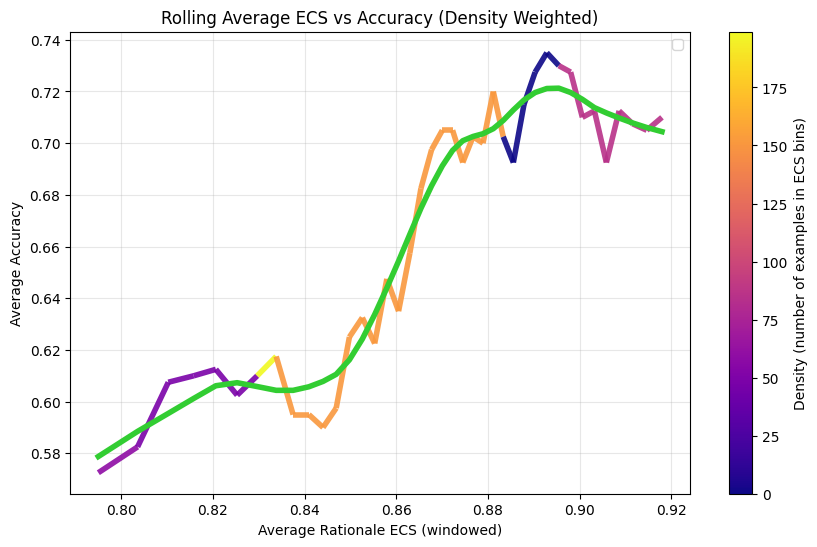

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------


ecs_file = "strategyQA__mistral_rationales_with_ecs.csv"
accuracy_file = "strategyQA__mistral_rationales_accuracy.csv"


# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
acc_df = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]

# Rename to match the rest of the script ("accuracy")
acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.078
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    overlapping_bins = bin_stats[(bin_stats["bin_mid"] >= ecs_min) &
                                 (bin_stats["bin_mid"] <= ecs_max)]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth high-density regions (LOWESS)
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # effectively no threshold, keeps all
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

smooth = lowess(acc_high, ecs_high, frac=0.30, return_sorted=True)

smooth_ecs = smooth[:, 0]
smooth_acc = smooth[:, 1]

ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4)

ax.legend()

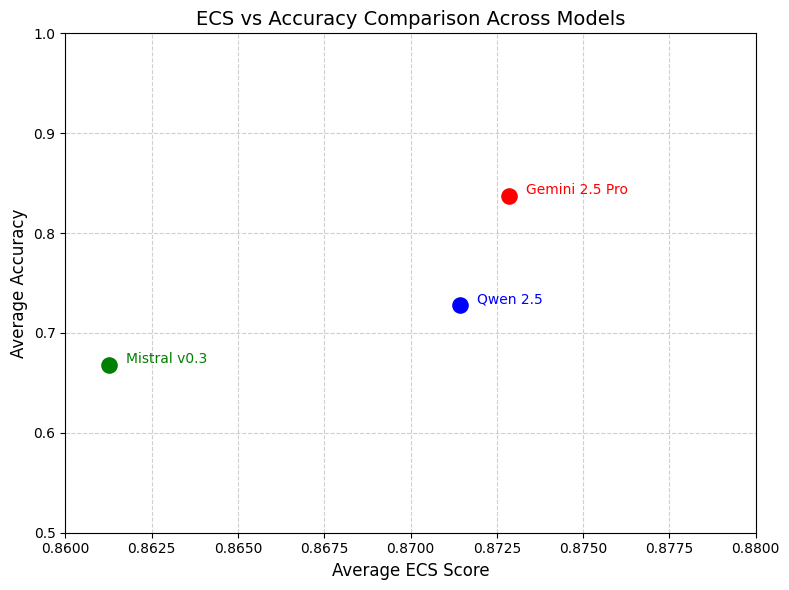

In [471]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. File paths (EDIT THESE IF NEEDED)
# ---------------------------------------------------------

# Gemini 2.5 Pro
ecs_gemini = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"
acc_gemini = "strategyqa_350_perturbed_accuracy.csv"

# Qwen 2.5
ecs_qwen = "strategyQA_answers_qwen2.5_trimmed_with_ecs.csv"
acc_qwen = "strategyqa_350_perturbed_qwen2.5_accuracy.csv"

# Mistral v0.3
ecs_mistral = "strategyQA__mistral_rationales_with_ecs.csv"
acc_mistral = "strategyQA__mistral_rationales_accuracy.csv"

# ---------------------------------------------------------
# 2. Function to load & merge ECS + accuracy by id
# ---------------------------------------------------------
def load_ecs_acc(ecs_file, acc_file):
    ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
    acc_df = pd.read_csv(acc_file)[["id", "row_accuracy"]]
    merged = ecs_df.merge(acc_df, on="id", how="inner")
    return merged

# Load all models
gemini = load_ecs_acc(ecs_gemini, acc_gemini)
qwen = load_ecs_acc(ecs_qwen, acc_qwen)
mistral = load_ecs_acc(ecs_mistral, acc_mistral)

# ---------------------------------------------------------
# 3. Compute average ECS and accuracy
# ---------------------------------------------------------
avg_ecs = {
    "Gemini 2.5 Pro": gemini["ECS"].mean(),
    "Qwen 2.5": qwen["ECS"].mean(),
    "Mistral v0.3": mistral["ECS"].mean(),
}

avg_accuracy = {
    "Gemini 2.5 Pro": gemini["row_accuracy"].mean(),
    "Qwen 2.5": qwen["row_accuracy"].mean(),
    "Mistral v0.3": mistral["row_accuracy"].mean(),
}

# Build lists for plotting
models = list(avg_ecs.keys())
ecs_vals = [avg_ecs[m] for m in models]
acc_vals = [avg_accuracy[m] for m in models]

# ---------------------------------------------------------
# 4. Plot ECS (X-axis) vs Accuracy (Y-axis)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# Assign a unique color to each model
colors = {
    "Gemini 2.5 Pro": "red",
    "Qwen 2.5": "blue",
    "Mistral v0.3": "green"
}

# Plot each point with its own color
for i, model in enumerate(models):
    plt.scatter(ecs_vals[i], acc_vals[i], s=120, color=colors[model])
    plt.text(
        ecs_vals[i] + 0.0005, 
        acc_vals[i] + 0.002, 
        model, 
        fontsize=10,
        color=colors[model]  # label matches dot color
    )

plt.xlabel("Average ECS Score", fontsize=12)
plt.ylabel("Average Accuracy", fontsize=12)
plt.title("ECS vs Accuracy Comparison Across Models", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)

# Custom boundaries
plt.xlim(0.86, 0.88)
plt.ylim(0.5, 1.0)

plt.tight_layout()
plt.show()




**accuracy calculated relied only on the original rationale**

In [1]:
import pandas as pd

# Input + Output files
input_file = "strategyqa_350_perturbed_gemini_final_answers.csv"
output_file = "strategyqa_350_perturbed_accuracy_detailed.csv"

# Load data
df = pd.read_csv(input_file)

# Columns containing extracted model answers
cols_to_check = [
    "original_answer",
    "lexical_answer",
    "syntactic_answer",
    "indirect_answer"
]

# Normalize gold answer for comparison
df["gold_answer"] = df["gold_answer"].astype(str).str.strip().str.capitalize()

# Loop through each perturbation column and calculate its specific accuracy
for col in cols_to_check:
    # Normalize the model answer
    df[col] = df[col].astype(str).str.strip().str.capitalize()
    
    # Create a new column name, e.g., 'original_accuracy', 'lexical_accuracy'
    acc_col_name = col.replace("_answer", "_accuracy")
    
    # Calculate binary accuracy (1 if match, 0 if not)
    # We use .astype(int) to make it 1/0 instead of True/False for easier plotting later
    df[acc_col_name] = (df[col] == df["gold_answer"]).astype(int)

# Optional: You can still calculate the mean row accuracy if you want to keep it
df["mean_accuracy"] = df[[c.replace("_answer", "_accuracy") for c in cols_to_check]].mean(axis=1)

# Save the results
df.to_csv(output_file, index=False)

print("🎉 Detailed accuracy computed!")
print(f"💾 Saved to: {output_file}")
print("\nPreview of accuracy columns:")
print(df[["id", "original_accuracy", "mean_accuracy"]].head())

🎉 Detailed accuracy computed!
💾 Saved to: strategyqa_350_perturbed_accuracy_detailed.csv

Preview of accuracy columns:
   id  original_accuracy  mean_accuracy
0   1                  1           1.00
1   2                  1           0.75
2   3                  1           1.00
3   4                  1           1.00
4   5                  0           0.25


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_61907/2008217580.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_61907/2008217580.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_61907/2008217580.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.leg

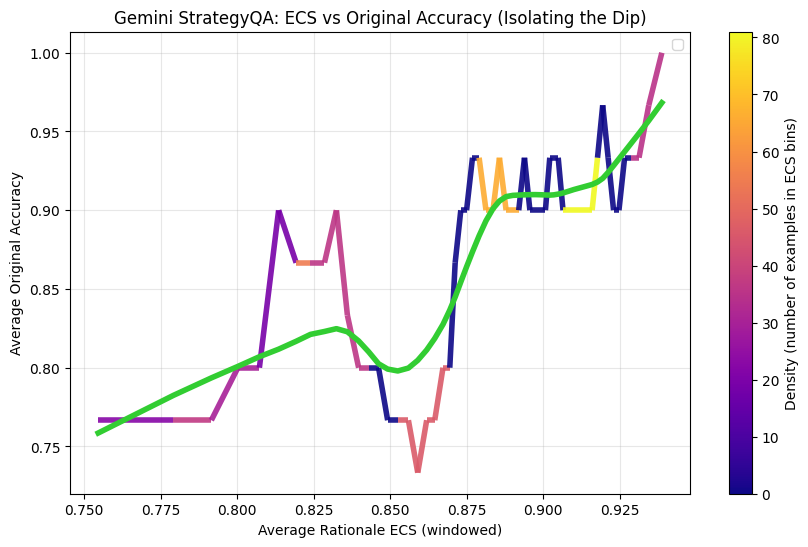

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths
# -----------------------------
# 1. File containing the calculated ECS scores
ecs_file = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"

# 2. NEW File containing the detailed accuracy columns
accuracy_file = "strategyqa_350_perturbed_accuracy_detailed.csv"

# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

# CRITICAL CHANGE: We select 'original_accuracy' instead of 'row_accuracy'
acc_df = pd.read_csv(accuracy_file)[["id", "original_accuracy"]]

# Rename to generic "accuracy" for the rest of the script
acc_df = acc_df.rename(columns={"original_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.027
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 30  # You mentioned window=50 in your description
step_size = 5     # You mentioned step=5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    # Safely handle empty bins in density calculation
    overlapping_bins = bin_stats[(bin_stats["bin_mid"] >= ecs_min) & 
                                 (bin_stats["bin_mid"] <= ecs_max)]
    
    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Original Accuracy")  # Updated Label
ax.set_title("Gemini StrategyQA: ECS vs Original Accuracy (Isolating the Dip)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth high-density regions (LOWESS)
# -----------------------------
# Ensure we have data before smoothing
if len(avg_ecs_list) > 0:
    density_threshold = np.percentile(window_density, 0)
    mask = np.array(window_density) >= density_threshold

    ecs_high = np.array(avg_ecs_list)[mask]
    acc_high = np.array(avg_acc_list)[mask]

    smooth = lowess(acc_high, ecs_high, frac=0.40, return_sorted=True)
    
    smooth_ecs = smooth[:, 0]
    smooth_acc = smooth[:, 1]
    
    ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4, label="")

ax.legend()
plt.show()

**Qwen 2.5**

In [6]:
import pandas as pd

# Input + Output files
input_file = "strategyqa_350_perturbed_qwen2.5_final_answers.csv"
# Renaming output to indicate it contains detailed breakdown
output_file = "strategyqa_350_perturbed_qwen2.5_accuracy_detailed.csv"

# Load data
df = pd.read_csv(input_file)

# Columns containing extracted model answers
cols_to_check = [
    "original_answer",
    "lexical_answer",
    "syntactic_answer",
    "indirect_answer"
]

# Normalize gold answer for comparison
# Note: Based on your snippet, the column in Qwen file is 'target_answer'
df["gold_answer"] = df["target_answer"].astype(str).str.strip().str.capitalize()

# Loop through each perturbation column and calculate its specific accuracy
for col in cols_to_check:
    # Normalize the model answer
    df[col] = df[col].astype(str).str.strip().str.capitalize()
    
    # Create a new column name, e.g., 'original_accuracy', 'lexical_accuracy'
    acc_col_name = col.replace("_answer", "_accuracy")
    
    # Calculate binary accuracy (1 if match, 0 if not)
    df[acc_col_name] = (df[col] == df["gold_answer"]).astype(int)

# Optional: Keep the mean accuracy for reference if needed
df["mean_accuracy"] = df[[c.replace("_answer", "_accuracy") for c in cols_to_check]].mean(axis=1)

# Save the results
df.to_csv(output_file, index=False)

print("🎉 Qwen 2.5 Detailed accuracy computed!")
print(f"💾 Saved to: {output_file}")
print("\nPreview of accuracy columns:")
print(df[["id", "original_accuracy", "mean_accuracy"]].head())

🎉 Qwen 2.5 Detailed accuracy computed!
💾 Saved to: strategyqa_350_perturbed_qwen2.5_accuracy_detailed.csv

Preview of accuracy columns:
   id  original_accuracy  mean_accuracy
0   1                  1           1.00
1   2                  1           1.00
2   3                  1           1.00
3   5                  0           0.25
4   6                  1           0.75


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/1881980186.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/1881980186.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()


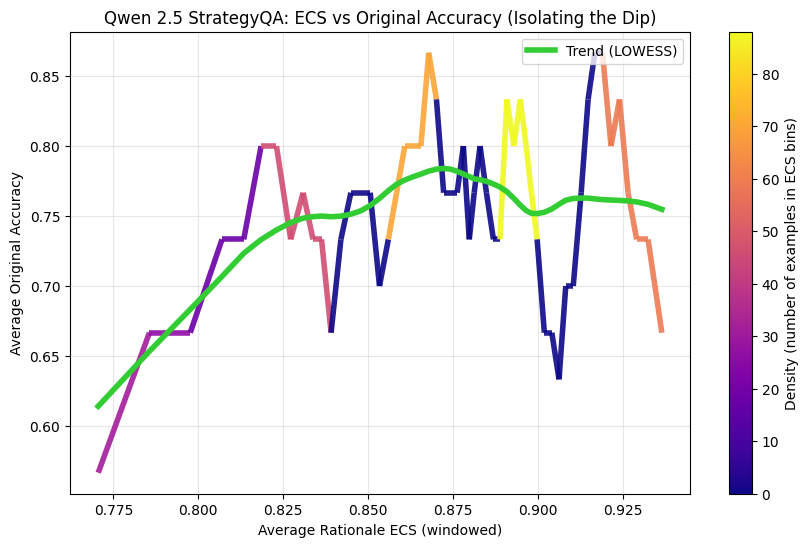

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths
# -----------------------------
# 1. File containing ECS scores (Make sure this matches your actual ECS filename)
ecs_file = "strategyQA_answers_qwen2.5_trimmed_with_ecs.csv"

# 2. NEW File containing the detailed accuracy columns
accuracy_file = "strategyqa_350_perturbed_qwen2.5_accuracy_detailed.csv"

# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

# CRITICAL CHANGE: Select 'original_accuracy' instead of 'row_accuracy'
acc_df = pd.read_csv(accuracy_file)[["id", "original_accuracy"]]

# Rename to generic "accuracy" so the rest of the script works without changes
acc_df = acc_df.rename(columns={"original_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.034
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
# Note: In your text you mentioned Window=50, Step=5. 
# The snippet provided had 30/5. I have kept 30/5 below, 
# but you can change window_size to 50 to match your other experiments.
window_size = 30 
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    
    # Filter bins that overlap with current window range
    overlapping_bins = bin_stats[(bin_stats["bin_mid"] >= ecs_min) & 
                                 (bin_stats["bin_mid"] <= ecs_max)]
    
    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Original Accuracy")  # Updated Label
ax.set_title("Qwen 2.5 StrategyQA: ECS vs Original Accuracy (Isolating the Dip)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth high-density regions (LOWESS)
# -----------------------------
if len(avg_ecs_list) > 0:
    density_threshold = np.percentile(window_density, 0)
    mask = np.array(window_density) >= density_threshold

    ecs_high = np.array(avg_ecs_list)[mask]
    acc_high = np.array(avg_acc_list)[mask]

    smooth = lowess(acc_high, ecs_high, frac=0.40, return_sorted=True)

    smooth_ecs = smooth[:, 0]
    smooth_acc = smooth[:, 1]

    ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4, label="Trend (LOWESS)")

ax.legend()
plt.show()

**mistral**

In [1]:
import pandas as pd

# -----------------------------
# Configuration
# -----------------------------
# IMPORTANT: Check that this input file matches your actual Mistral filename
input_file = "strategyQA_answers_mistral2.5_final_answers_with_targets.csv" 

# Output file for the detailed breakdown
output_file = "strategyQA_mistral_accuracy_detailed.csv"

# -----------------------------
# Processing
# -----------------------------
# Load data
try:
    df = pd.read_csv(input_file)
    print(f"📄 Loaded {len(df)} rows from {input_file}")
except FileNotFoundError:
    print(f"❌ Error: Could not find file '{input_file}'. Please check the filename.")
    exit()

# Columns containing extracted model answers
cols_to_check = [
    "original_answer",
    "lexical_answer",
    "syntactic_answer",
    "indirect_answer"
]

# Normalize gold answer for comparison
# Using 'target_answer' as seen in your snippet
df["gold_answer"] = df["target_answer"].astype(str).str.strip().str.capitalize()

# Loop through each perturbation column and calculate its specific accuracy
for col in cols_to_check:
    # Normalize the model answer
    df[col] = df[col].astype(str).str.strip().str.capitalize()
    
    # Create a new column name, e.g., 'original_accuracy', 'lexical_accuracy'
    acc_col_name = col.replace("_answer", "_accuracy")
    
    # Calculate binary accuracy (1 if match, 0 if not)
    df[acc_col_name] = (df[col] == df["gold_answer"]).astype(int)

# Optional: Calculate mean accuracy if you still want to compare later
df["mean_accuracy"] = df[[c.replace("_answer", "_accuracy") for c in cols_to_check]].mean(axis=1)

# -----------------------------
# Save Results
# -----------------------------
df.to_csv(output_file, index=False)

print("🎉 Mistral detailed accuracy computed!")
print(f"💾 Saved to: {output_file}")
print("\nPreview of accuracy columns:")
print(df[["id", "original_accuracy", "mean_accuracy"]].head())

📄 Loaded 297 rows from strategyQA_answers_mistral2.5_final_answers_with_targets.csv
🎉 Mistral detailed accuracy computed!
💾 Saved to: strategyQA_mistral_accuracy_detailed.csv

Preview of accuracy columns:
   id  original_accuracy  mean_accuracy
0   1                  1           1.00
1   2                  1           1.00
2   3                  1           1.00
3   4                  0           0.50
4   5                  0           0.25


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_3213/136187744.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_3213/136187744.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_3213/136187744.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


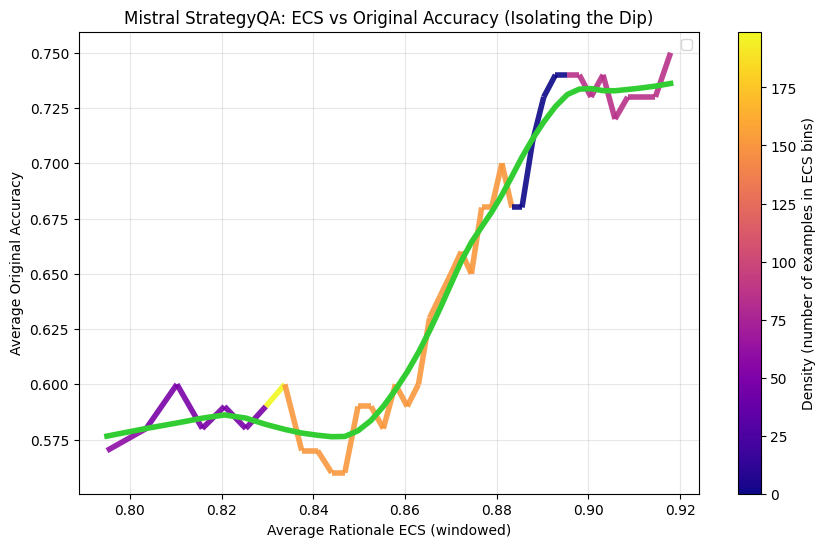

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths
# -----------------------------
# 1. ECS File (Make sure this matches your actual ECS filename)
ecs_file = "strategyQA__mistral_rationales_with_ecs.csv"

# 2. NEW File containing the detailed accuracy columns
accuracy_file = "strategyQA_mistral_accuracy_detailed.csv"

# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]

# CRITICAL CHANGE: Select 'original_accuracy' instead of 'row_accuracy'
acc_df = pd.read_csv(accuracy_file)[["id", "original_accuracy"]]

# Rename to generic "accuracy" so the rest of the script works without changes
acc_df = acc_df.rename(columns={"original_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
# Note: You used bin_width=0.078 in your snippet, which is quite large. 
# If the graph looks blocky, try reducing this to ~0.03.
bin_width = 0.078
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
# You used window=100 in the snippet. This is high and might smooth out the "Dip".
# If the dip disappears, try lowering this back to 50.
window_size = 100
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    
    # Filter bins that overlap with current window range
    overlapping_bins = bin_stats[(bin_stats["bin_mid"] >= ecs_min) & 
                                 (bin_stats["bin_mid"] <= ecs_max)]
    
    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Original Accuracy")  # Updated Label
ax.set_title("Mistral StrategyQA: ECS vs Original Accuracy (Isolating the Dip)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth high-density regions (LOWESS)
# -----------------------------
if len(avg_ecs_list) > 0:
    density_threshold = np.percentile(window_density, 0)
    mask = np.array(window_density) >= density_threshold

    ecs_high = np.array(avg_ecs_list)[mask]
    acc_high = np.array(avg_acc_list)[mask]

    smooth = lowess(acc_high, ecs_high, frac=0.30, return_sorted=True)

    smooth_ecs = smooth[:, 0]
    smooth_acc = smooth[:, 1]

    ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4, label="")

ax.legend()
plt.show()

In [4]:
!pip -q install sentence-transformers tqdm

import pandas as pd
import numpy as np
from itertools import combinations
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer

# =====================================================
# CONFIGURATION
# =====================================================
input_file = "strategyqa_350_perturbed_gemini_rationales.csv"
output_file = "strategyqa_350_perturbed_gemini_rationales_multi_ecs.csv"

# Define the column names for your rationales
cols = {
    "orig": "original_answer",
    "lex": "lexical_answer",
    "syn": "syntactic_answer",
    "ind": "indirect_answer"
}

# =====================================================
# STEP 1: Load Data & Model
# =====================================================
df = pd.read_csv(input_file)
print(f"📄 Loaded {len(df)} rows from {input_file}")

print("🚀 Loading embedding model: all-MiniLM-L6-v2 ...")
model = SentenceTransformer("all-MiniLM-L6-v2")

# =====================================================
# STEP 2: Define the Groups to Measure
# =====================================================
# We will calculate ECS for these specific subsets of columns
groups = {
    # Baseline (All 4)
    "ECS_all": ["orig", "lex", "syn", "ind"],
    
    # Triplets (Leave one out)
    "ECS_no_indirect":  ["orig", "lex", "syn"],
    "ECS_no_syntactic": ["orig", "lex", "ind"],
    "ECS_no_lexical":   ["orig", "syn", "ind"],
    
    # Pairs (Strict comparisons to Original)
    "ECS_orig_lex": ["orig", "lex"],
    "ECS_orig_syn": ["orig", "syn"],
    "ECS_orig_ind": ["orig", "ind"],
}

# =====================================================
# STEP 3: Optimized Computation Loop
# =====================================================
# storage for new columns
results = {key: [] for key in groups.keys()}

print("🧮 Computing multiple ECS variations...")

for _, row in tqdm(df.iterrows(), total=len(df)):
    # 1. Extract texts
    texts_map = {}
    valid_keys = []
    raw_texts = []
    
    # keys are 'orig', 'lex', etc.
    for key, col_name in cols.items():
        txt = row.get(col_name)
        if isinstance(txt, str) and txt.strip():
            texts_map[key] = txt
            valid_keys.append(key)
            raw_texts.append(txt)
    
    # 2. Encode ALL valid texts at once (Much faster)
    if not raw_texts:
        embeddings = []
    else:
        embeddings = model.encode(raw_texts, normalize_embeddings=True)
    
    # Map key -> embedding vector
    emb_map = {k: v for k, v in zip(valid_keys, embeddings)}

    # 3. Calculate ECS for each group
    for group_name, required_keys in groups.items():
        # Filter to keys that actually exist in this row (handle missing data)
        current_keys = [k for k in required_keys if k in emb_map]
        
        if len(current_keys) < 2:
            results[group_name].append(np.nan)
            continue
            
        # Get vectors
        vecs = [emb_map[k] for k in current_keys]
        
        # Calculate cosine sim for all unique pairs in this group
        pairs = list(combinations(vecs, 2))
        sims = [float(np.dot(a, b)) for a, b in pairs]
        
        results[group_name].append(np.mean(sims))

# =====================================================
# STEP 4: Add to DataFrame & Save
# =====================================================
for col_name, values in results.items():
    df[col_name] = values

df.to_csv(output_file, index=False)
print(f"\n💾 Saved extended results to {output_file}")
print("New columns created:")
print(list(results.keys()))


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 311 rows from strategyqa_350_perturbed_gemini_rationales.csv
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing multiple ECS variations...


  0%|          | 0/311 [00:00<?, ?it/s]


💾 Saved extended results to strategyqa_350_perturbed_gemini_rationales_multi_ecs.csv
New columns created:
['ECS_all', 'ECS_no_indirect', 'ECS_no_syntactic', 'ECS_no_lexical', 'ECS_orig_lex', 'ECS_orig_syn', 'ECS_orig_ind']


🚀 Generating 7 comparison plots...


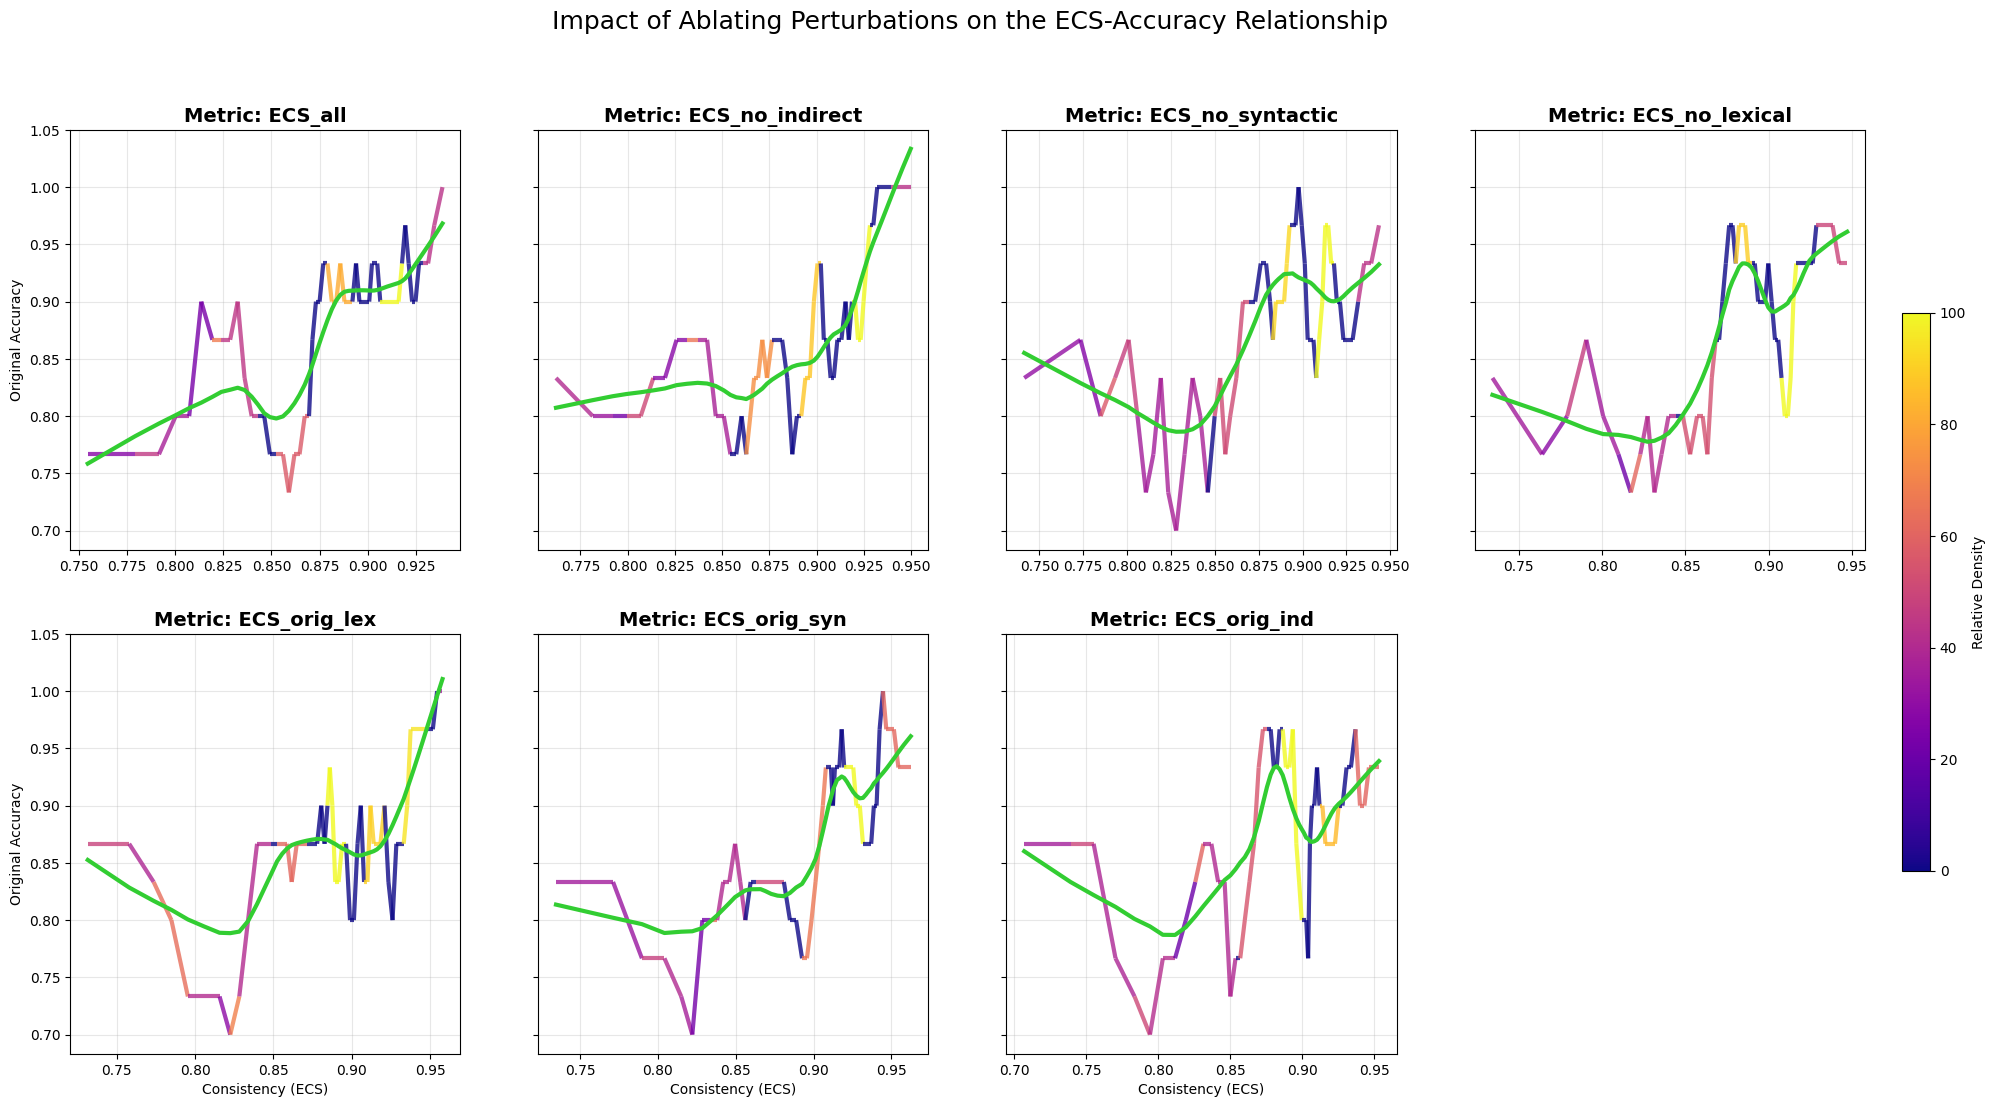

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# CONFIGURATION
# -----------------------------
ecs_file = "strategyqa_350_perturbed_gemini_rationales_multi_ecs.csv"
accuracy_file = "strategyqa_350_perturbed_accuracy_detailed.csv"

# The 7 metrics we want to compare
ecs_columns = [
    "ECS_all",
    "ECS_no_indirect", "ECS_no_syntactic", "ECS_no_lexical",
    "ECS_orig_lex", "ECS_orig_syn", "ECS_orig_ind"
]

# -----------------------------
# 1. Load & Merge Data
# -----------------------------
# Load ECS file (all columns)
ecs_full_df = pd.read_csv(ecs_file)

# Load Accuracy (Only Original Accuracy)
acc_df = pd.read_csv(accuracy_file)[["id", "original_accuracy"]]
acc_df = acc_df.rename(columns={"original_accuracy": "accuracy"})

# Merge
master_df = acc_df.merge(ecs_full_df, on="id", how="left")

# -----------------------------
# 2. Setup Plotting Grid
# -----------------------------
# Create a 2x4 grid (7 plots + 1 empty)
fig, axes = plt.subplots(2, 4, figsize=(24, 12), sharey=True)
axes = axes.flatten()  # Flatten 2D array to 1D for easy looping

# Global parameters
window_size = 30
step_size = 5
bin_width = 0.027

print("🚀 Generating 7 comparison plots...")

# -----------------------------
# 3. Loop through each ECS Metric
# -----------------------------
for i, ecs_col in enumerate(ecs_columns):
    ax = axes[i]
    
    # Isolate data for this specific metric
    # Drop NaNs (some pairs might be missing if text was empty)
    df = master_df[["id", "accuracy", ecs_col]].dropna()
    df = df.rename(columns={ecs_col: "ECS"}) # Standardize name for processing
    df = df.sort_values("ECS").reset_index(drop=True)

    # --- Density Calculation ---
    bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
    df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)
    
    bin_stats = df.groupby("ecs_bin", observed=True).agg(
        density=("id", "count"),
        bin_mid=("ECS", "mean")
    ).reset_index()

    # --- Sliding Window ---
    avg_ecs_list = []
    avg_acc_list = []
    window_density = []

    for start in range(0, len(df) - window_size + 1, step_size):
        window = df.iloc[start:start + window_size]
        
        # Means
        avg_ecs_list.append(window["ECS"].mean())
        avg_acc_list.append(window["accuracy"].mean())
        
        # Density Sum
        ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
        subset = bin_stats[(bin_stats["bin_mid"] >= ecs_min) & (bin_stats["bin_mid"] <= ecs_max)]
        window_density.append(subset["density"].sum())

    # --- Plotting the ZigZag Line ---
    if len(avg_ecs_list) > 1:
        points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        # Normalize colors based on density
        norm = Normalize(vmin=min(window_density), vmax=max(window_density))
        colors = cm.plasma(norm(window_density[:-1]))

        lc = LineCollection(segments, colors=colors, linewidth=3, alpha=0.8)
        ax.add_collection(lc)
        
        # --- LOWESS Trend Line (Green) ---
        smooth = lowess(avg_acc_list, avg_ecs_list, frac=0.40, return_sorted=True)
        ax.plot(smooth[:, 0], smooth[:, 1], color="#32CD32", linewidth=3, label="Trend")

    # Formatting
    ax.autoscale()
    ax.set_title(f"Metric: {ecs_col}", fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    if i >= 4: # Bottom row
        ax.set_xlabel("Consistency (ECS)")
    if i % 4 == 0: # Left column
        ax.set_ylabel("Original Accuracy")

# -----------------------------
# 4. Final Cleanup
# -----------------------------
# Hide the 8th unused subplot (since we have 7 metrics)
axes[7].axis('off')

# Add a single colorbar for reference
sm = cm.ScalarMappable(cmap=cm.plasma, norm=Normalize(vmin=0, vmax=100)) # Approx scale
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), location='right', fraction=0.015, pad=0.02)
cbar.set_label("Relative Density")

plt.suptitle("Impact of Ablating Perturbations on the ECS-Accuracy Relationship", fontsize=18)
plt.show()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
📄 Loaded 297 rows from strategyQA__mistral_rationales_cleaned.csv
🚀 Loading embedding model: all-MiniLM-L6-v2 ...
🧮 Computing multiple ECS variations for Mistral...


  0%|          | 0/297 [00:00<?, ?it/s]


💾 Saved extended results to strategyQA_mistral_rationales_multi_ecs.csv
New columns created:
['ECS_all', 'ECS_no_indirect', 'ECS_no_syntactic', 'ECS_no_lexical', 'ECS_orig_lex', 'ECS_orig_syn', 'ECS_orig_ind']


🚀 Generating 7 comparison plots for Mistral...


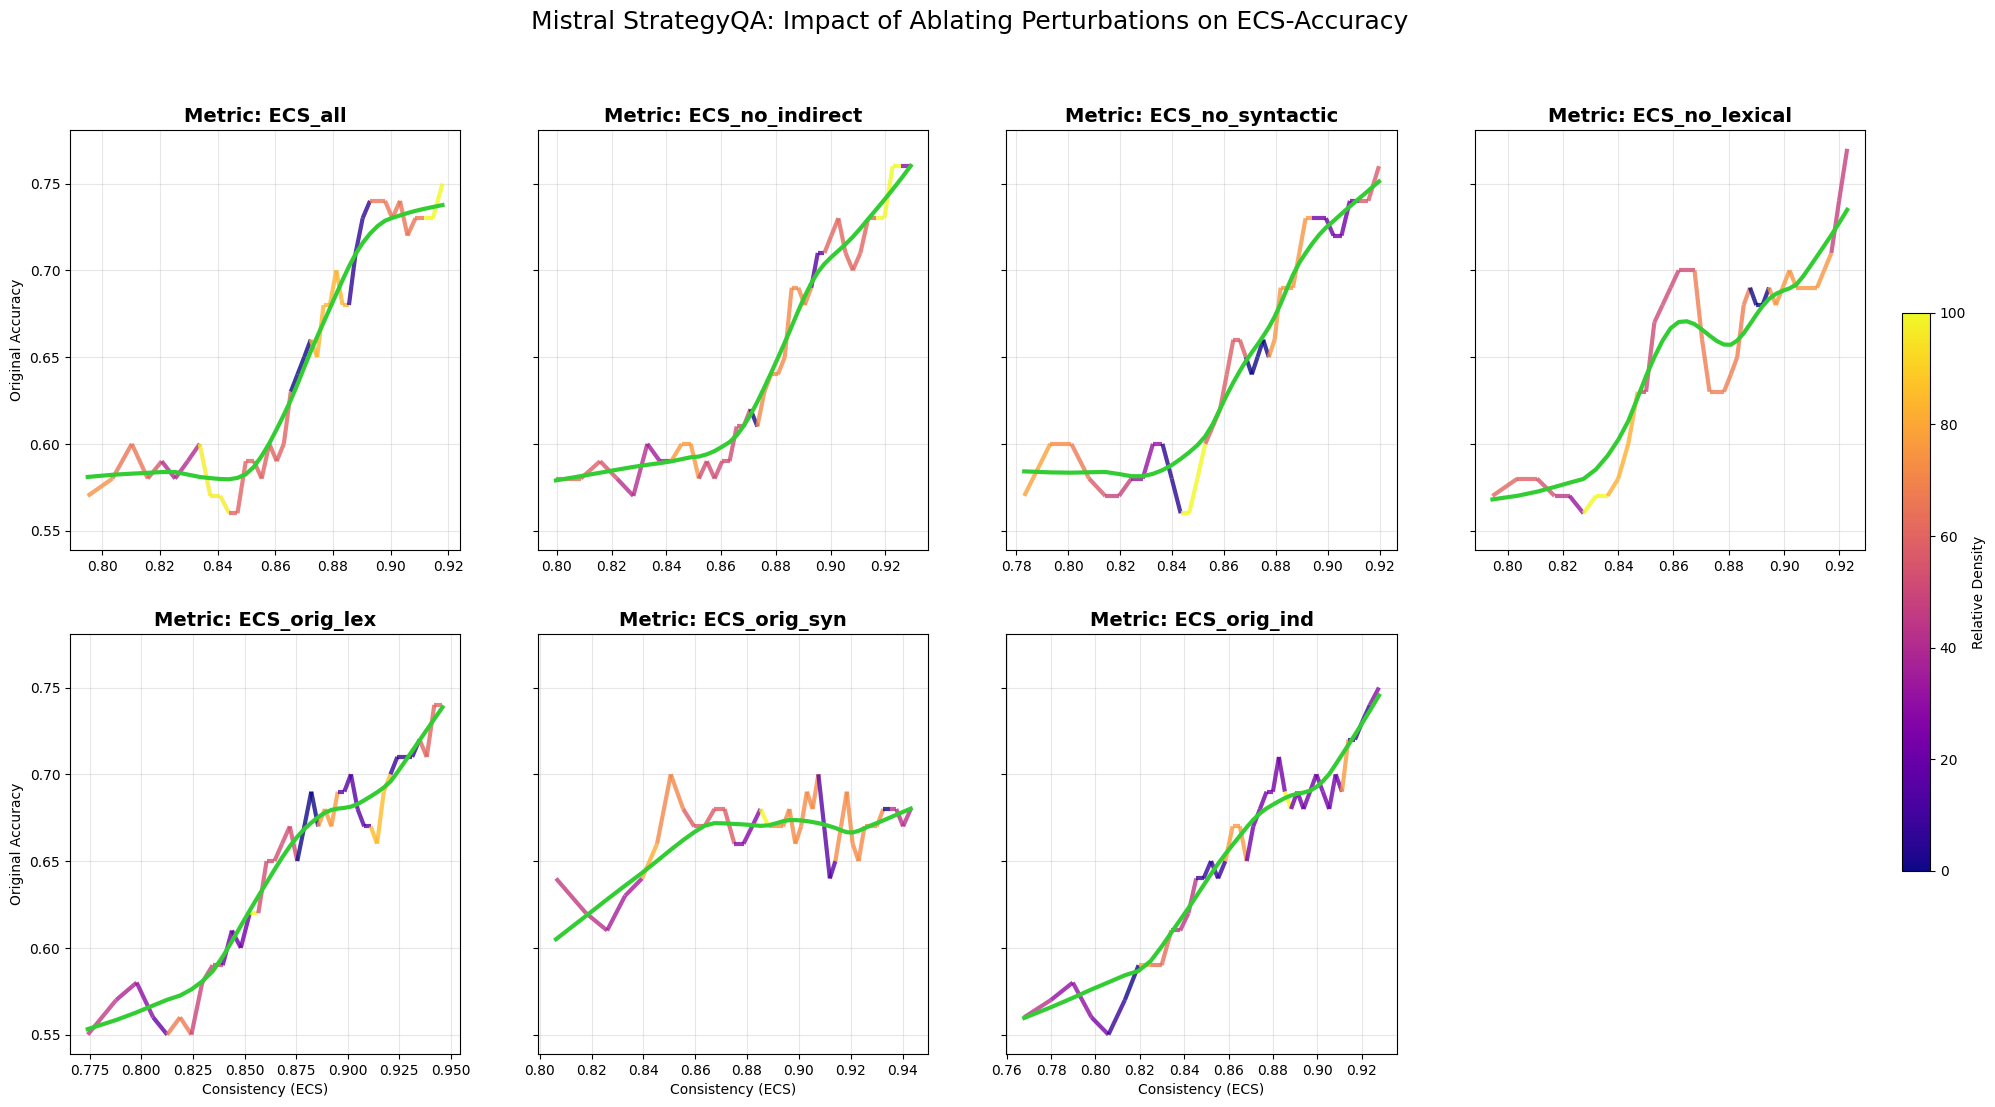

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# CONFIGURATION
# -----------------------------
# UPDATED: Mistral File Paths
ecs_file = "strategyQA_mistral_rationales_multi_ecs.csv"
accuracy_file = "strategyQA_mistral_accuracy_detailed.csv"

# The 7 metrics we want to compare
ecs_columns = [
    "ECS_all",
    "ECS_no_indirect", "ECS_no_syntactic", "ECS_no_lexical",
    "ECS_orig_lex", "ECS_orig_syn", "ECS_orig_ind"
]

# -----------------------------
# 1. Load & Merge Data
# -----------------------------
# Load ECS file (all columns)
ecs_full_df = pd.read_csv(ecs_file)

# Load Accuracy (Only Original Accuracy)
acc_df = pd.read_csv(accuracy_file)[["id", "original_accuracy"]]
acc_df = acc_df.rename(columns={"original_accuracy": "accuracy"})

# Merge
master_df = acc_df.merge(ecs_full_df, on="id", how="left")

# -----------------------------
# 2. Setup Plotting Grid
# -----------------------------
# Create a 2x4 grid (7 plots + 1 empty)
fig, axes = plt.subplots(2, 4, figsize=(24, 12), sharey=True)
axes = axes.flatten()  # Flatten 2D array to 1D for easy looping

# Global parameters
window_size = 100
step_size = 5
bin_width = 0.027

print("🚀 Generating 7 comparison plots for Mistral...")

# -----------------------------
# 3. Loop through each ECS Metric
# -----------------------------
for i, ecs_col in enumerate(ecs_columns):
    ax = axes[i]
    
    # Isolate data for this specific metric
    # Drop NaNs (some pairs might be missing if text was empty)
    # Check if column exists to avoid errors
    if ecs_col in master_df.columns:
        df = master_df[["id", "accuracy", ecs_col]].dropna()
        df = df.rename(columns={ecs_col: "ECS"}) # Standardize name for processing
        df = df.sort_values("ECS").reset_index(drop=True)

        # --- Density Calculation ---
        # Handle case where all ECS values are the same (creates empty bins)
        if df["ECS"].nunique() > 1:
            bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
        else:
            bins = np.linspace(0, 1, 10)
            
        df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)
        
        bin_stats = df.groupby("ecs_bin", observed=True).agg(
            density=("id", "count"),
            bin_mid=("ECS", "mean")
        ).reset_index()

        # --- Sliding Window ---
        avg_ecs_list = []
        avg_acc_list = []
        window_density = []

        for start in range(0, len(df) - window_size + 1, step_size):
            window = df.iloc[start:start + window_size]
            
            # Means
            avg_ecs_list.append(window["ECS"].mean())
            avg_acc_list.append(window["accuracy"].mean())
            
            # Density Sum
            ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
            # Safely get density
            subset = bin_stats[(bin_stats["bin_mid"] >= ecs_min) & (bin_stats["bin_mid"] <= ecs_max)]
            window_density.append(subset["density"].sum())

        # --- Plotting the ZigZag Line ---
        if len(avg_ecs_list) > 1:
            points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            # Normalize colors based on density
            norm = Normalize(vmin=min(window_density), vmax=max(window_density))
            colors = cm.plasma(norm(window_density[:-1]))

            lc = LineCollection(segments, colors=colors, linewidth=3, alpha=0.8)
            ax.add_collection(lc)
            
            # --- LOWESS Trend Line (Green) ---
            try:
                smooth = lowess(avg_acc_list, avg_ecs_list, frac=0.40, return_sorted=True)
                ax.plot(smooth[:, 0], smooth[:, 1], color="#32CD32", linewidth=3, label="Trend")
            except Exception as e:
                print(f"Skipping LOWESS for {ecs_col} due to data shape.")

    # Formatting
    ax.autoscale()
    ax.set_title(f"Metric: {ecs_col}", fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    if i >= 4: # Bottom row
        ax.set_xlabel("Consistency (ECS)")
    if i % 4 == 0: # Left column
        ax.set_ylabel("Original Accuracy")

# -----------------------------
# 4. Final Cleanup
# -----------------------------
# Hide the 8th unused subplot (since we have 7 metrics)
axes[7].axis('off')

# Add a single colorbar for reference
sm = cm.ScalarMappable(cmap=cm.plasma, norm=Normalize(vmin=0, vmax=100)) # Approx scale
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), location='right', fraction=0.015, pad=0.02)
cbar.set_label("Relative Density")

plt.suptitle("Mistral StrategyQA: Impact of Ablating Perturbations on ECS-Accuracy", fontsize=18)
plt.show()

**LLM-as-a-judge**

In [19]:
import os
import json
import pathlib
import pandas as pd
from tqdm import tqdm
import csv
import time
from vertexai.generative_models import GenerativeModel, GenerationConfig
import vertexai
from google.api_core.exceptions import ResourceExhausted, ServiceUnavailable

# ---------------------------
# 1. GOOGLE AUTHENTICATION
# ---------------------------
# 🔥 Change this path to where your JSON file is stored:
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"

assert os.path.exists(SERVICE_ACCOUNT_PATH), f"❌ JSON file not found: {SERVICE_ACCOUNT_PATH}"

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
print("✅ Google service account loaded from:", SERVICE_ACCOUNT_PATH)

# ---------------------------
# 2. INITIALIZE GEMINI (Vertex AI)
# ---------------------------
vertexai.init(project="llm-reasoning-475315", location="us-central1")

# CORRECT MODEL as requested
model = GenerativeModel("gemini-2.5-flash")

print("✅ Gemini model initialized (gemini-2.5-flash).")

# ---------------------------
# 3. CONFIGURATION & FILES
# ---------------------------
input_file = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"
output_file = "strategyqa_logic_ecs_pairwise_detailed_FULL.csv"

# Column mapping
col_map = {
    "A": "original_answer",
    "B": "lexical_answer",
    "C": "syntactic_answer",
    "D": "indirect_answer"
}

# ---------------------------
# 4. ROBUST API FUNCTION (With Retry)
# ---------------------------
def get_pairwise_prompt(text1, text2):
    return f"""You are an expert logic evaluator. I will provide two rationales (Rationale 1 and Rationale 2) generated by an AI for the SAME question.

Your task: Determine if they are **logically consistent** with each other.

Ignore minor wording differences or length. Focus strictly on:
1. Do they rely on the same core facts?
2. Do they use the same reasoning steps?
3. Do they reach the same conclusion?

--- Rationale 1 ---
{text1}

--- Rationale 2 ---
{text2}

Answer with a simple JSON object:
{{
  "consistent": 1, 
  "reason": "short explanation"
}}
Use 1 if they are logically equivalent, 0 if they contradict or use fundamentally different logic.
"""

def check_consistency(text1, text2, max_retries=5):
    # Basic input validation
    if not isinstance(text1, str) or not isinstance(text2, str): return 0
    if not text1.strip() or not text2.strip(): return 0

    prompt = get_pairwise_prompt(text1, text2)
    
    # --- RETRY LOOP ---
    for attempt in range(max_retries):
        try:
            response = model.generate_content(
                prompt,
                generation_config=GenerationConfig(response_mime_type="application/json")
            )
            result = json.loads(response.text)
            return int(result.get("consistent", 0))

        except (ResourceExhausted, ServiceUnavailable) as e:
            # Handle 429 Quota Exceeded
            wait_time = (2 ** attempt) + 1  # 2s, 3s, 5s, 9s, 17s...
            print(f"⚠️ Quota hit. Pausing for {wait_time}s... (Attempt {attempt+1}/{max_retries})")
            time.sleep(wait_time)
            
        except Exception as e:
            # Non-recoverable error
            print(f"❌ API Error: {e}")
            return 0
            
    print("❌ Max retries reached for this pair. Skipping.")
    return 0

# ---------------------------
# 5. DATA LOADING & RESUME LOGIC
# ---------------------------
df = pd.read_csv(input_file)
print(f"📄 Input data: {len(df)} rows.")

# Define the 6 pairs
pairs_to_check = [("A", "B"), ("A", "C"), ("A", "D"), ("B", "C"), ("B", "D"), ("C", "D")]
output_columns = ["id", "Semantic_ECS"] + [f"score_{p1}{p2}" for p1, p2 in pairs_to_check] + ["Logic_ECS"]

# Check if we can resume
processed_ids = set()
if os.path.exists(output_file):
    try:
        existing_df = pd.read_csv(output_file)
        if "id" in existing_df.columns:
            processed_ids = set(existing_df["id"].unique())
            print(f"🔄 Resuming... Found {len(processed_ids)} already processed rows.")
    except:
        print("⚠️ Output file exists but couldn't be read. Starting fresh.")
else:
    # Initialize file with headers
    pd.DataFrame(columns=output_columns).to_csv(output_file, index=False)
    print(f"🆕 Created {output_file} with headers.")

# Filter to only rows that haven't been done
df_to_process = df[~df["id"].isin(processed_ids)]
print(f"🚀 Starting processing on {len(df_to_process)} remaining rows...")

# ---------------------------
# 6. MAIN LOOP
# ---------------------------
for index, row in tqdm(df_to_process.iterrows(), total=len(df_to_process)):
    row_result = {"id": row["id"], "Semantic_ECS": row.get("ECS", 0)}
    pair_scores = []
    
    for p1_key, p2_key in pairs_to_check:
        t1 = row.get(col_map[p1_key], "")
        t2 = row.get(col_map[p2_key], "")
        
        score = check_consistency(t1, t2)
        
        row_result[f"score_{p1_key}{p2_key}"] = score
        pair_scores.append(score)
        
        # Base sleep to respect rate limits
        time.sleep(1.0) 
    
    if pair_scores:
        row_result["Logic_ECS"] = sum(pair_scores) / len(pair_scores)
    else:
        row_result["Logic_ECS"] = 0
        
    # --- IMMEDIATE SAVE ---
    single_row_df = pd.DataFrame([row_result], columns=output_columns)
    single_row_df.to_csv(output_file, mode='a', header=False, index=False)

print("\n✅ Full Evaluation Complete!")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Google service account loaded from: llm-reasoning-475315-b0391b898b58.json
✅ Gemini model initialized (gemini-2.5-flash).
📄 Input data: 311 rows.
🆕 Created strategyqa_logic_ecs_pairwise_detailed_FULL.csv with headers.
🚀 Starting processing on 311 remaining rows...


100%|███████████████████████████████████████| 311/311 [3:22:04<00:00, 38.99s/it]


✅ Full Evaluation Complete!


✅ Plotting data for 311 examples.


/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_3213/1526174496.py:139: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


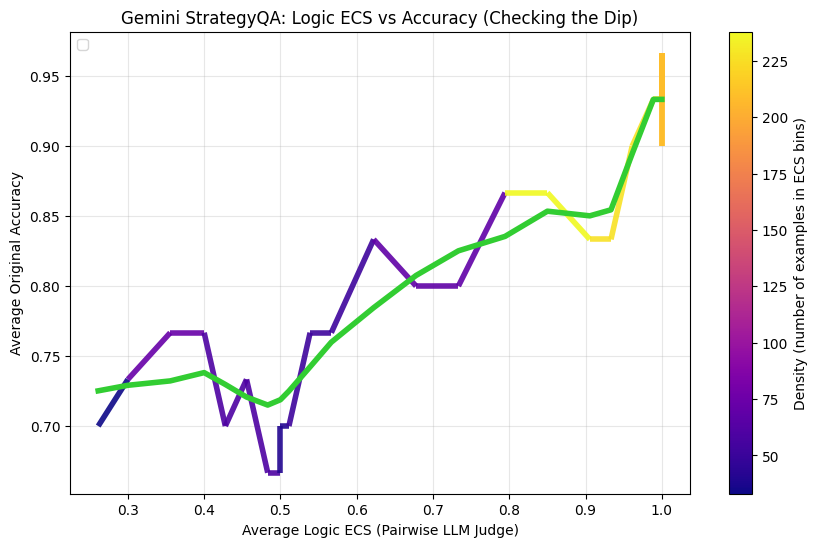

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths
# -----------------------------
# 1. NEW File containing the Logic ECS scores (LLM-as-a-Judge)
ecs_file = "strategyqa_logic_ecs_pairwise_detailed_FULL.csv"

# 2. File containing the detailed accuracy columns
accuracy_file = "strategyqa_350_perturbed_accuracy_detailed.csv"

# -----------------------------
# Load data
# -----------------------------
# Load the Logic ECS column and rename it to "ECS" for compatibility
try:
    ecs_df = pd.read_csv(ecs_file)
    # Check if Logic_ECS exists (it should based on your previous script)
    if "Logic_ECS" in ecs_df.columns:
        ecs_df = ecs_df[["id", "Logic_ECS"]].rename(columns={"Logic_ECS": "ECS"})
    else:
        # Fallback if the file isn't fully ready or headers differ
        print(f"⚠️ 'Logic_ECS' column not found. Available columns: {ecs_df.columns}")
        # Attempt to calculate it if pairwise scores exist but mean is missing
        cols = [c for c in ecs_df.columns if c.startswith("score_")]
        if cols:
            print("🔄 Recalculating mean Logic_ECS from pairwise columns...")
            ecs_df["ECS"] = ecs_df[cols].mean(axis=1)
            ecs_df = ecs_df[["id", "ECS"]]
except FileNotFoundError:
    print(f"❌ Error: File {ecs_file} not found.")
    exit()

# Load Accuracy (Original Question Only)
acc_df = pd.read_csv(accuracy_file)[["id", "original_accuracy"]]
acc_df = acc_df.rename(columns={"original_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="inner") # Use inner to ensure we have both scores
df = df.dropna(subset=["ECS", "accuracy"]) # Drop any rows where logic check failed/is NaN
df = df.sort_values("ECS").reset_index(drop=True)

print(f"✅ Plotting data for {len(df)} examples.")

# -----------------------------
# Bin ECS to compute density
# -----------------------------
# Logic ECS is discrete (0, 0.16, 0.33, etc.), so bins will naturally cluster
bin_width = 0.05 
bins = np.arange(0, 1.0 + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins, include_lowest=True)

bin_density = df.groupby("ecs_bin", observed=False)["id"].count()
bin_mid = df.groupby("ecs_bin", observed=False)["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).dropna().reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 30 
step_size = 5     

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    
    # Sum density of bins covered by this window
    overlapping_bins = bin_stats[
        (bin_stats["bin_mid"] >= ecs_min - 0.01) & 
        (bin_stats["bin_mid"] <= ecs_max + 0.01)
    ]
    
    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
if len(avg_ecs_list) > 1:
    points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(vmin=min(window_density), vmax=max(window_density))
    colors = cm.plasma(norm(window_density[:-1]))

    lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

    # -----------------------------
    # Create plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.add_collection(lc)
    ax.autoscale()
    ax.set_xlabel("Average Logic ECS (Pairwise LLM Judge)")
    ax.set_ylabel("Average Original Accuracy") 
    ax.set_title("Gemini StrategyQA: Logic ECS vs Accuracy (Checking the Dip)")
    ax.grid(alpha=0.3)

    # -----------------------------
    # Colorbar
    # -----------------------------
    sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Density (number of examples in ECS bins)")

    # -----------------------------
    # Smooth high-density regions (LOWESS)
    # -----------------------------
    # Ensure we have data before smoothing
    try:
        smooth = lowess(avg_acc_list, avg_ecs_list, frac=0.2, return_sorted=True)
        smooth_ecs = smooth[:, 0]
        smooth_acc = smooth[:, 1]
        ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4, label="")
    except Exception as e:
        print(f"Smoothing skipped: {e}")

    ax.legend(loc="upper left")
    plt.show()
else:
    print("❌ Not enough data points to plot. Check if the merged dataframe is empty.")

✅ Saved plot as PDF: strategyqa-qwen.pdf


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/958859553.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/958859553.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/958859553.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend

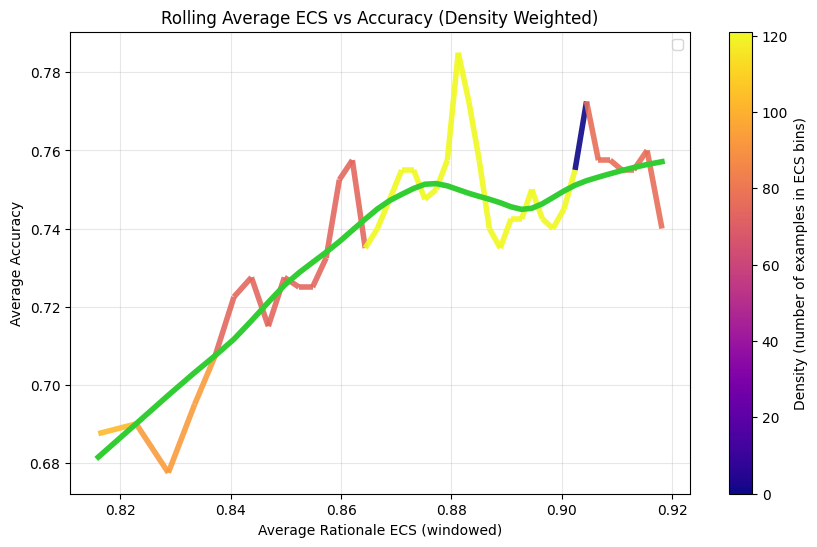

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------

ecs_file = "strategyQA_answers_qwen2.5_trimmed_with_ecs.csv"
accuracy_file = "strategyqa_350_perturbed_qwen2.5_accuracy.csv"

# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
acc_df = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]

# Rename to match the rest of the script ("accuracy")
acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.05
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 100
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    overlapping_bins = bin_stats[(bin_stats["bin_mid"] >= ecs_min) &
                                 (bin_stats["bin_mid"] <= ecs_max)]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth high-density regions (LOWESS)
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # effectively no threshold, keeps all
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

smooth = lowess(acc_high, ecs_high, frac=0.40, return_sorted=True)

smooth_ecs = smooth[:, 0]
smooth_acc = smooth[:, 1]

# Added label for legend
ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4, label="")

ax.legend()

# -----------------------------
# SAVE AS PDF (NEW CODE HERE)
# -----------------------------
pdf_filename = "strategyqa-qwen.pdf"
plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")
print(f"✅ Saved plot as PDF: {pdf_filename}")

plt.show()

✅ Saved plot as PDF: strategyqa-gemini.pdf


/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/1735525351.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_density = df.groupby("ecs_bin")["id"].count()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/1735525351.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_mid = df.groupby("ecs_bin")["ECS"].mean()
/var/folders/vk/18ngtwrs58n0x_sklvrh_58h0000gn/T/ipykernel_98186/1735525351.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.leg

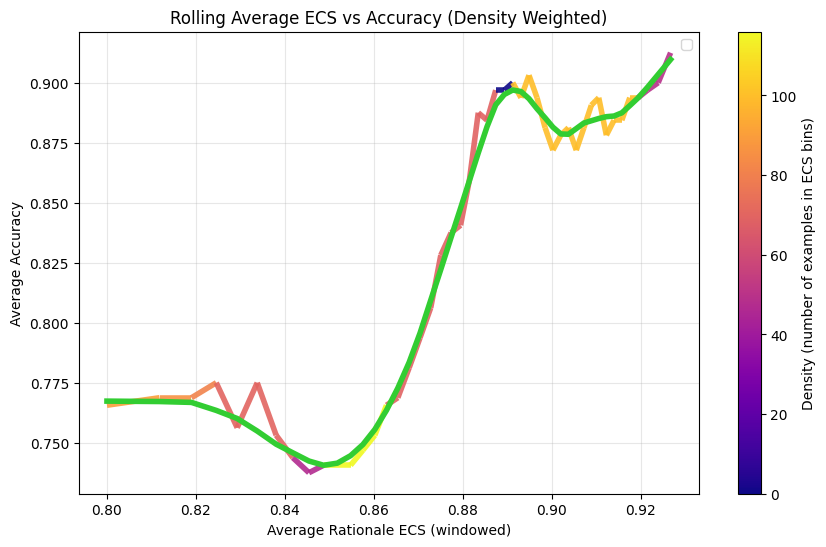

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# File paths (YOUR FILES)
# -----------------------------
ecs_file = "strategyqa_350_perturbed_gemini_rationales_with_ecs.csv"
accuracy_file = "strategyqa_350_perturbed_accuracy.csv"

# -----------------------------
# Load data
# -----------------------------
ecs_df = pd.read_csv(ecs_file)[["id", "ECS"]]
acc_df = pd.read_csv(accuracy_file)[["id", "row_accuracy"]]

# Rename to match the rest of the script ("accuracy")
acc_df = acc_df.rename(columns={"row_accuracy": "accuracy"})

# Merge into one dataset
df = acc_df.merge(ecs_df, on="id", how="left")
df = df.sort_values("ECS").reset_index(drop=True)

# -----------------------------
# Bin ECS to compute density
# -----------------------------
bin_width = 0.034
bins = np.arange(df["ECS"].min(), df["ECS"].max() + bin_width, bin_width)
df["ecs_bin"] = pd.cut(df["ECS"], bins=bins)

bin_density = df.groupby("ecs_bin")["id"].count()
bin_mid = df.groupby("ecs_bin")["ECS"].mean()

bin_stats = pd.DataFrame({
    "bin_mid": bin_mid,
    "density": bin_density
}).reset_index(drop=True)

# -----------------------------
# Rolling window parameters
# -----------------------------
window_size = 80
step_size = 5

avg_ecs_list = []
avg_acc_list = []
window_density = []

# -----------------------------
# Compute rolling averages and assign density
# -----------------------------
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]

    avg_ecs_list.append(window["ECS"].mean())
    avg_acc_list.append(window["accuracy"].mean())

    ecs_min, ecs_max = window["ECS"].min(), window["ECS"].max()
    overlapping_bins = bin_stats[(bin_stats["bin_mid"] >= ecs_min) &
                                 (bin_stats["bin_mid"] <= ecs_max)]

    window_density.append(overlapping_bins["density"].sum())

# -----------------------------
# Prepare colored zigzag line
# -----------------------------
points = np.array([avg_ecs_list, avg_acc_list]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=min(window_density), vmax=max(window_density))
colors = cm.plasma(norm(window_density[:-1]))

lc = LineCollection(segments, colors=colors, linewidth=4, alpha=0.9)

# -----------------------------
# Create plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.add_collection(lc)
ax.autoscale()
ax.set_xlabel("Average Rationale ECS (windowed)")
ax.set_ylabel("Average Accuracy")
ax.set_title("Rolling Average ECS vs Accuracy (Density Weighted)")
ax.grid(alpha=0.3)

# -----------------------------
# Colorbar
# -----------------------------
sm = cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Density (number of examples in ECS bins)")

# -----------------------------
# Smooth high-density regions (LOWESS)
# -----------------------------
density_threshold = np.percentile(window_density, 0)  # effectively no threshold, keeps all
mask = np.array(window_density) >= density_threshold

ecs_high = np.array(avg_ecs_list)[mask]
acc_high = np.array(avg_acc_list)[mask]

smooth = lowess(acc_high, ecs_high, frac=0.19, return_sorted=True)

smooth_ecs = smooth[:, 0]
smooth_acc = smooth[:, 1]

# Added label for legend
ax.plot(smooth_ecs, smooth_acc, color="#32CD32", linewidth=4, label="")

ax.legend()

# -----------------------------
# SAVE AS PDF (NEW CODE HERE)
# -----------------------------
pdf_filename = "strategyqa-gemini.pdf"
plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")
print(f"✅ Saved plot as PDF: {pdf_filename}")

plt.show()